<a href="https://colab.research.google.com/github/Lievaashini/Lieva---ML/blob/main/wid3006_assignment_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Group Assignment: Tying the (Data) Knot: Love, Life & Likes**
Project Title: Interest-Based Matching: Predicting User Interests via Digital Behavior



---


**Group Members:**

WONG XIANG HONG |

KAMILIA AHLAM TAQI BINTI TAQI MOHAMED | 24001462

SHAHITYA SHRI A/P SRI KRISHNAH | 25006586

LIEVASHINI A/P THANASEGARAN | 25006877

HARSHINI A/P KUMARA VELL | 24064079

TIGITRA |


Objective: To develop a machine learning model that predicts a user's primary interests by analyzing their app interaction patterns (swipe ratios, usage time, and engagement metrics).



---


# Data Loading & Setup

In [ ]:
# Data Handling & Math
import pandas as pd  # Used to load and clean 50,000 records
import numpy as np   # Used for high-level mathematical functions

# Data Pre-processing
from sklearn.model_selection import train_test_split  # To split data 80/20
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Visualization (To see patterns)
import matplotlib.pyplot as plt
import seaborn as sns

# Download files to computer
from google.colab import files

In [ ]:
from google.colab import files

# Import the dataset from our source directory.
# This converts the comma-separated values into a structured table format.
# Upload the file if it's not already in the /content/ directory.
uploaded = files.upload()

df = pd.read_csv('/content/dating_app_behavior_dataset.csv')

# Allow us to inspect the first five rows
# Ensure that column headers are correctly aligned
df.head()

Saving dating_app_behavior_dataset.csv to dating_app_behavior_dataset.csv


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like




---


# Data Integrity Check

In [ ]:
df.info() # "Objects" that need to be turn into numbers
df.dtypes # To check the data types of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6   app_usage_time_min    50000 non-null  int64  
 7   app_usage_time_label  50000 non-null  object 
 8   swipe_right_ratio     50000 non-null  float64
 9   swipe_right_label     50000 non-null  object 
 10  likes_received        50000 non-null  int64  
 11  mutual_matches        50000 non-null  int64  
 12  profile_pics_count    50000 non-null  int64  
 13  bio_length            50000 non-null  int64  
 14  message_sent_count    50000 non-null  int64  
 15  emoji_usage_rate   

,0
gender,object
sexual_orientation,object
location_type,object
income_bracket,object
education_level,object
interest_tags,object
app_usage_time_min,int64
app_usage_time_label,object
swipe_right_ratio,float64
swipe_right_label,object


In [ ]:
df.isnull().sum() # show how many empty spots are in each column
# shown 0 means no empty spots in all the columns

,0
gender,0
sexual_orientation,0
location_type,0
income_bracket,0
education_level,0
interest_tags,0
app_usage_time_min,0
app_usage_time_label,0
swipe_right_ratio,0
swipe_right_label,0


In [ ]:
df.shape # To confirm that there are 50 000 records and 19 columns

(50000, 19)



---

# Data Cleaning

In [ ]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check data types
print(df.dtypes)

# Basic statistics
df.describe()

Duplicate rows: 0
gender                   object
sexual_orientation       object
location_type            object
income_bracket           object
education_level          object
interest_tags            object
app_usage_time_min        int64
app_usage_time_label     object
swipe_right_ratio       float64
swipe_right_label        object
likes_received            int64
mutual_matches            int64
profile_pics_count        int64
bio_length                int64
message_sent_count        int64
emoji_usage_rate        float64
last_active_hour          int64
swipe_time_of_day        object
match_outcome            object
dtype: object


,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000




---

# Data Structuring

In [ ]:
# Select Features (X) and Target (y)
X = df [['app_usage_time_min', 'swipe_right_ratio', 'income_bracket', 'education_level', 'likes_received', 'mutual_matches']]
y = df ['interest_tags']

In [ ]:
# Convert the string of interests into lists
# This splits the text by the comma and removes extra spaces
df['Interest_List'] = df['interest_tags'].apply(lambda x: [i.strip() for i in x.split(',')])



---

# Data Pre-Processing

###  1.0 Feature Encoding

We used `MultiLabelBinarizer` because our `interest_tags` contain multiple values per user. Predicting only the first tag would lose valuable behavioral data

In [ ]:
# Initialize binarizer
mlb = MultiLabelBinarizer()

# Transform the list of interests into a matrix of 0s and 1s
y_binarized = mlb.fit_transform(df['Interest_List'])

# Create a new DataFrame to see the results
y_df = pd.DataFrame(y_binarized, columns=mlb.classes_)

# Check the first few rows
print(y_df.head())

len(mlb.classes_)

   Anime  Art  Astrology  Binge-Watching  Board Games  Cars  Clubbing  Coding  \
0      0    0          0               0            0     0         0       0   
1      0    0          0               0            0     0         0       0   
2      0    0          0               0            0     0         0       0   
3      0    0          0               0            0     0         0       1   
4      0    0          0               0            0     1         1       0   

   Cooking  Crafting  ...  Sneaker Culture  Social Activism  Spirituality  \
0        0         0  ...                0                0             0   
1        0         0  ...                0                0             0   
2        0         0  ...                0                0             0   
3        0         0  ...                0                0             0   
4        0         0  ...                0                0             0   

   Stand-up Comedy  Startups  Tattoos  Tech  Trave

49

In [ ]:
# Perform a train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_df, test_size=0.2, random_state=42)

# Save features (X) and the 49-column interest matrix (y)
X_train.to_csv('X_train_final.csv', index=False)
X_test.to_csv('X_test_final.csv', index=False)
y_train.to_csv('y_train_multi.csv', index=False)
y_test.to_csv('y_test_multi.csv', index=False)

To confirm that `y_train` and `y_test` DataFrames contain the binarized 'interest_tags' and ensure consistency with the corresponding `X` sets, We need to print their shapes :



In [ ]:
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of y_train: (40000, 49)
Shape of y_test: (10000, 49)


We applied `pd.get_dummies` to the `income_bracket` and `education_level` columns. This technique creates new binary columns (0 or 1) for each unique category. We chose One-Hot Encoding over Label Encoding to avoid implying a mathematical hierarchy (e.g., preventing the model from assuming "Master's" is numerically "greater than" "Bachelor's")

In [ ]:
# One-Hot Encode the remaining text columns
# Turns 'income_bracket' and 'education_level' into 0s and 1s
X_train_encoded = pd.get_dummies(X_train, columns=['income_bracket', 'education_level'])
X_test_encoded = pd.get_dummies(X_test, columns=['income_bracket', 'education_level'])

We used the `.align()` function to ensure that both the Training and Testing sets contain the exact same columns. This is a critical step; if the test set is missing a category that appeared in the training set (or vice versa), the model would fail to execute. Any missing columns in the test set are filled with 0 to maintain consistency.

In [ ]:
# Ensure both train and test have the same columns after encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

###  2.0 Feature Scaling

We applied `StandardScaler` to the features because models like KNN and Logistic Regression are sensitive to the scale of the data. Without this, `likes_received` (values up to 200) would unfairly dominate `swipe_right_ratio` (values between 0 and 1).

In [ ]:
# Apply Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)



---


# Exploratory Data Analysis (EDA)

The bar chart shows that interests like `Tech` and `Fitness` are highly prevalent, but there is a wide variety across the 49 tags, confirming that users have diverse profiles.

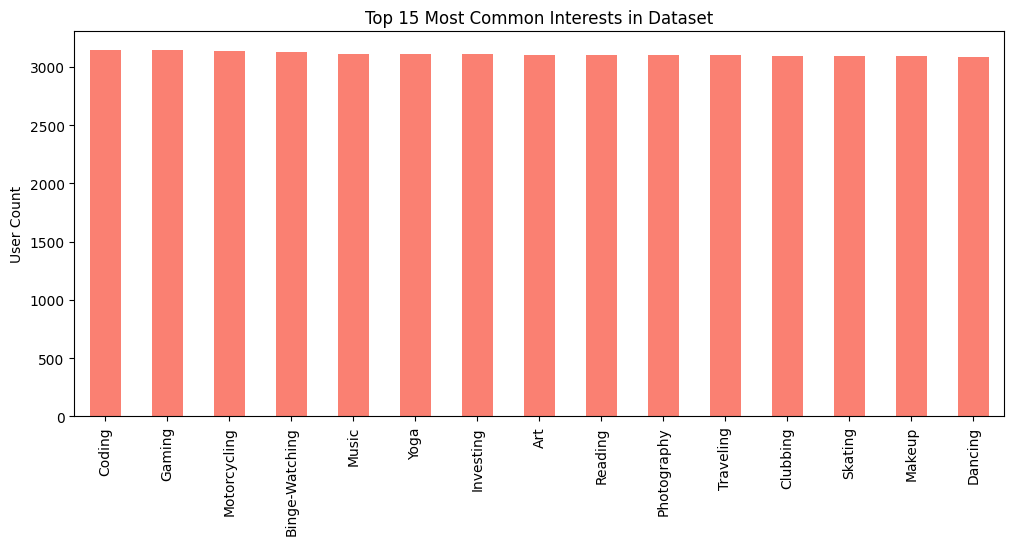

In [ ]:
# Visualize the most popular interests
plt.figure(figsize=(12,5))
y_df.sum().sort_values(ascending=False).head(15).plot(kind='bar', color='salmon')
plt.title('Top 15 Most Common Interests in Dataset')
plt.ylabel('User Count')
plt.show()

The heatmap indicates how swipe ratios correlate with actual matches. This ensures our features have enough "signal" to help the model make accurate predictions.

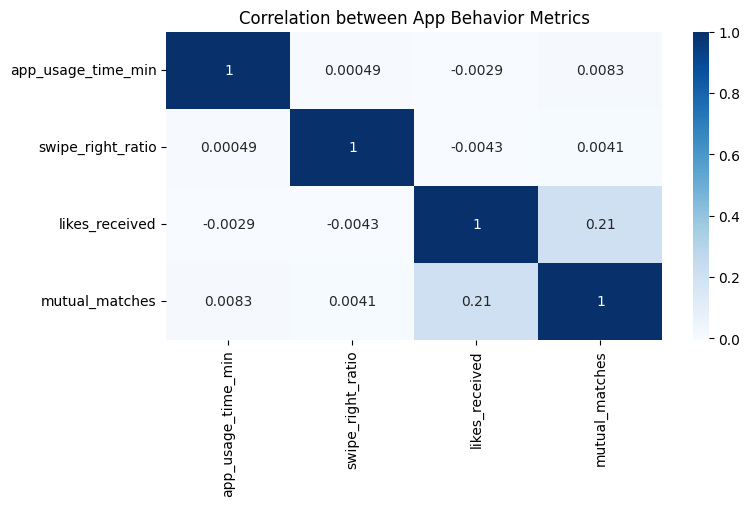

In [ ]:
# Check the correlation of our interaction behaviors
plt.figure(figsize=(8,4))
sns.heatmap(X[['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'mutual_matches']].corr(), annot=True, cmap='Blues')
plt.title('Correlation between App Behavior Metrics')
plt.show()

To visualize the distribution of key numerical features using box plots

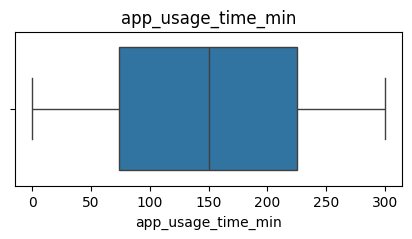

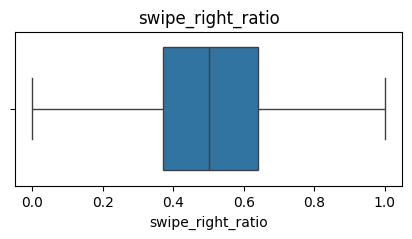

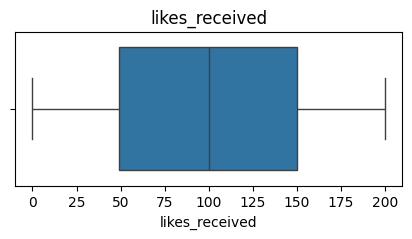

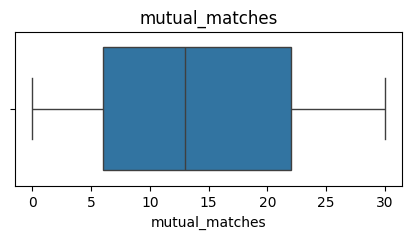

In [ ]:
numerical_cols = ['app_usage_time_min', 'swipe_right_ratio',
                  'likes_received', 'mutual_matches']

for col in numerical_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()



---

# Data Validation

Machine Learning Models # New Section

In [ ]:
import pandas as pd

# Convert back to DataFrame to save
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

# Save and export new files
X_train_final.to_csv('X_train_scaled_fixed.csv', index=False)
X_test_final.to_csv('X_test_scaled_fixed.csv', index=False)

In [ ]:
# Ensure the features are numeric and targets are ready
print("Features (X) Shape:", X_train_final.shape)
print("Target (y) Shape:", y_train.shape)
print("\nFirst 5 rows of processed features:")
X_train_final.head()

Features (X) Shape: (40000, 20)
Target (y) Shape: (40000, 49)

First 5 rows of processed features:


,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,income_bracket_High,income_bracket_Low,income_bracket_Lower-Middle,income_bracket_Middle,income_bracket_Upper-Middle,income_bracket_Very High,income_bracket_Very Low,education_level_Associate’s,education_level_Bachelor’s,education_level_Diploma,education_level_High School,education_level_MBA,education_level_Master’s,education_level_No Formal Education,education_level_PhD,education_level_Postdoc
0,-0.216334,-1.574840,0.750409,-0.536186,-0.413307,-0.405691,-0.409361,-0.407110,2.445070,-0.408445,-0.404813,2.856135,-0.357192,-0.350168,-0.35857,-0.354919,-0.351157,-0.354428,-0.354249,-0.351112
1,1.555644,0.504677,1.112601,1.439485,-0.413307,-0.405691,-0.409361,-0.407110,-0.408986,2.448312,-0.404813,-0.350123,-0.357192,-0.350168,-0.35857,-0.354919,2.847726,-0.354428,-0.354249,-0.351112
2,1.198947,-0.864761,-0.284426,-1.414263,-0.413307,-0.405691,-0.409361,2.456336,-0.408986,-0.408445,-0.404813,-0.350123,-0.357192,-0.350168,-0.35857,-0.354919,2.847726,-0.354428,-0.354249,-0.351112
3,1.463593,-0.915481,-0.767349,-0.316667,-0.413307,-0.405691,-0.409361,-0.407110,-0.408986,-0.408445,2.470278,-0.350123,-0.357192,-0.350168,-0.35857,-0.354919,-0.351157,-0.354428,2.822873,-0.351112
4,0.405009,1.519076,-1.715948,-1.524022,-0.413307,2.464932,-0.409361,-0.407110,-0.408986,-0.408445,-0.404813,-0.350123,-0.357192,2.855768,-0.35857,-0.354919,-0.351157,-0.354428,-0.354249,-0.351112


# Group 47 raw interests to 6 broader categories

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Load files ─────────────────────────
X_train_final = pd.read_csv('X_train_scaled_fixed.csv')
X_test_final  = pd.read_csv('X_test_scaled_fixed.csv')

# ── Get interest_group target from original dataset ───────
df = pd.read_csv('dating_app_behavior_dataset.csv')

interest_groups = {
    'Active & Outdoors': ['Fitness', 'Hiking', 'Running', 'Skating', 'MMA', 'Dancing', 'Yoga'],
    'Creative':          ['Art', 'Painting', 'Photography', 'Writing', 'Poetry', 'Crafting', 'DIY'],
    'Entertainment':     ['Clubbing', 'Movies', 'Music', 'Memes', 'Gaming', 'Anime', 'K-pop', 'Binge-Watching', 'Stand-up Comedy'],
    'Intellectual':      ['Coding', 'Tech', 'History', 'Politics', 'Reading', 'Podcasts', 'Languages', 'Investing', 'Startups'],
    'Lifestyle':         ['Cooking', 'Foodie', 'Fashion', 'Makeup', 'Pets', 'Parenting', 'Traveling', 'Tattoos', 'Sneaker Culture'],
    'Mindful':           ['Meditation', 'Spirituality', 'Astrology', 'Gardening', 'Board Games', 'Motorcycling', 'Cars']
}

interest_to_group = {}
for group, interests in interest_groups.items():
    for interest in interests:
        interest_to_group[interest] = group

df['primary_interest'] = df['interest_tags'].str.split(',').str[0].str.strip()
df['interest_group']   = df['primary_interest'].map(interest_to_group)

# ── Recreate exact same split
_, _, y_train, y_test = train_test_split(
    df.drop(columns=['interest_group']),
    df['interest_group'],
    test_size=0.2, random_state=42
)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# ── Verify ────────────────────────────────────────────────
print("X_train shape:", X_train_final.shape)
print("y_train shape:", y_train.shape)
print("Unmapped:", df[df['interest_group'].isna()]['primary_interest'].unique())
print("Class distribution:\n", y_train.value_counts())

X_train shape: (40000, 20)
y_train shape: (40000,)
Unmapped: ['Social Activism']
Class distribution:
 interest_group
Lifestyle            7385
Entertainment        7366
Intellectual         7330
Mindful              5738
Creative             5716
Active & Outdoors    5658
Name: count, dtype: int64


In [ ]:
# ── Check how many are unmapped ───────────────────────────
print("NaN count:", y_train.isna().sum())

# ── Drop NaN rows from both X and y ──────────────────────
nan_mask = y_train.notna()
X_train_final = X_train_final[nan_mask].reset_index(drop=True)
y_train = y_train[nan_mask].reset_index(drop=True)

nan_mask_test = y_test.notna()
X_test_final = X_test_final[nan_mask_test].reset_index(drop=True)
y_test = y_test[nan_mask_test].reset_index(drop=True)

# ── Verify ────────────────────────────────────────────────
print("X_train shape:", X_train_final.shape)
print("y_train shape:", y_train.shape)
print("Classes:", y_train.unique())
print("Class distribution:\n", y_train.value_counts())

NaN count: 807
X_train shape: (39193, 20)
y_train shape: (39193,)
Classes: ['Intellectual' 'Entertainment' 'Lifestyle' 'Active & Outdoors' 'Mindful'
 'Creative']
Class distribution:
 interest_group
Lifestyle            7385
Entertainment        7366
Intellectual         7330
Mindful              5738
Creative             5716
Active & Outdoors    5658
Name: count, dtype: int64


# Machine Learning Models Training - Decision Tree, KNN, Logistic Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# ── KNN ───────────────────────────────────────────────────
knn_params = {
    'n_neighbors': [3, 5, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
knn_grid.fit(X_train_final, y_train)
print("Best KNN params:", knn_grid.best_params_)
print("KNN CV Accuracy:", round(knn_grid.best_score_, 4))
print("KNN Test Accuracy:", round(accuracy_score(y_test, knn_grid.predict(X_test_final)), 4))

# ── Logistic Regression ───────────────────────────────────
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['saga'],
    'max_iter': [2000]
}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    lr_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_final, y_train)
print("Best LR params:", lr_grid.best_params_)
print("LR CV Accuracy:", round(lr_grid.best_score_, 4))
print("LR Test Accuracy:", round(accuracy_score(y_test, lr_grid.predict(X_test_final)), 4))

# ── Final Evaluation ──────────────────────────────────────
models = {
    "KNN":                 knn_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_,
}

for name, model in models.items():
    y_pred = model.predict(X_test_final)
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy: {round(accuracy_score(y_test, y_pred), 4)}")
    print(classification_report(y_test, y_pred, zero_division=0))

import joblib

# ── Save all 3 tuned models ───────────────────────────────
joblib.dump(knn_grid.best_estimator_, 'model_knn.pkl')
joblib.dump(lr_grid.best_estimator_,  'model_logistic_regression.pkl')

print("Models saved!")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best DT params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
DT CV Accuracy: 0.1707
DT Test Accuracy: 0.1675
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best KNN params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
KNN CV Accuracy: 0.1698
KNN Test Accuracy: 0.1768
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best LR params: {'C': 1, 'max_iter': 2000, 'solver': 'saga'}
LR CV Accuracy: 0.1661
LR Test Accuracy: 0.168

  Decision Tree
  Accuracy: 0.1675
                   precision    recall  f1-score   support

Active & Outdoors       0.14      0.15      0.14      1412
         Creative       0.15      0.16      0.15      1387
    Entertainment       0.19      0.18      0.19      1875
     Intellectual       0.19      0.20      0.20      1829
        Lifestyle       0.18      0.17      0.18      1866
          Mindful       0.13      0.13      0.13      142

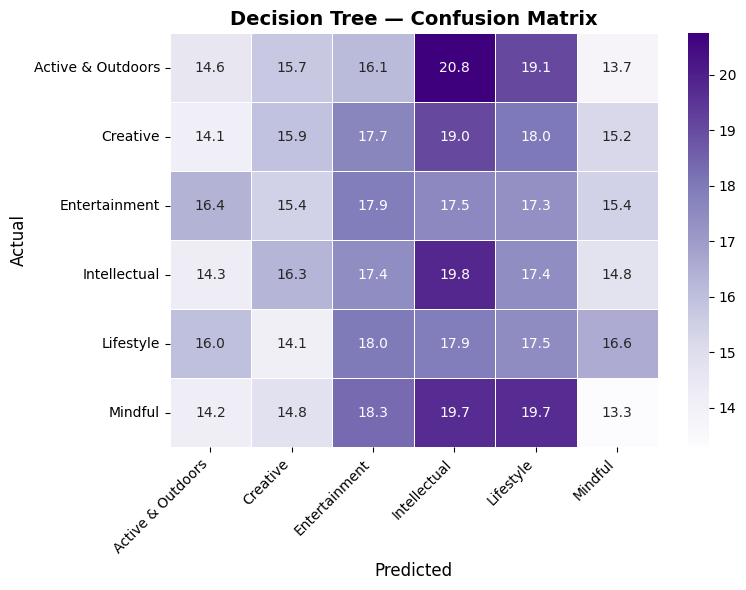

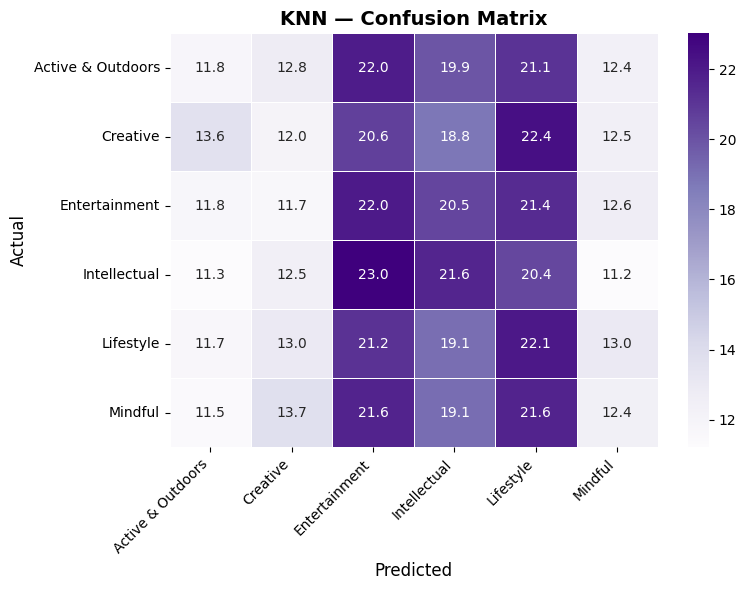

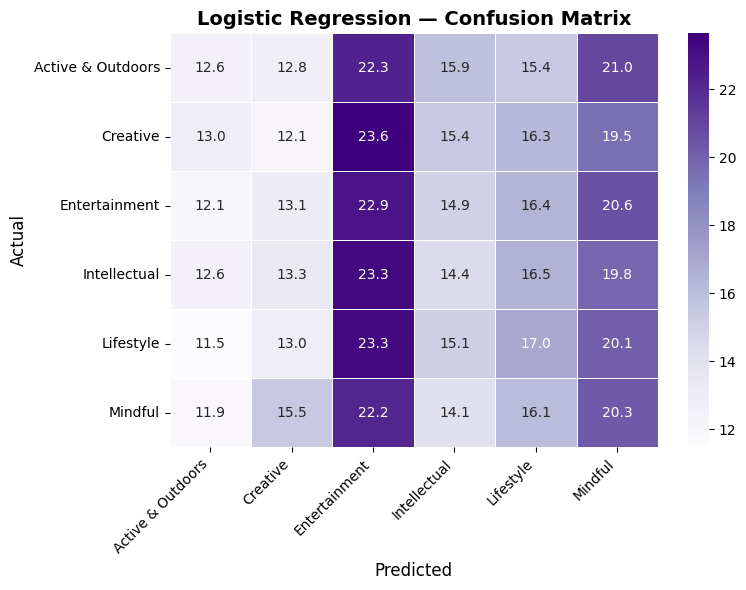

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

class_names = ['Active & Outdoors', 'Creative', 'Entertainment',
               'Intellectual', 'Lifestyle', 'Mindful']

models = {
    "Decision Tree":       dt_grid.best_estimator_,
    "KNN":                 knn_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_,
}

for name, model in models.items():
    y_pred = model.predict(X_test_final)

    cm = confusion_matrix(y_test, y_pred)

    # Normalize to percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_percent,
        annot=True,
        fmt='.1f',
        cmap='Purples',
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5
    )
    plt.title(f'{name} — Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('Actual', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


---

# **Machine Learning Models**





## Decision Tree Models ##

Match Outcome Classes:
match_outcome
One-sided Like         5112
Instant Match          5078
Blocked                5049
Catfished              5025
Chat Ignored           5019
Mutual Match           4990
No Action              4986
Ghosted                4959
Date Happened          4919
Relationship Formed    4863
Name: count, dtype: int64

Total Classes: 10

Encoded Classes: ['Blocked' 'Catfished' 'Chat Ignored' 'Date Happened' 'Ghosted'
 'Instant Match' 'Mutual Match' 'No Action' 'One-sided Like'
 'Relationship Formed']

Decision Tree Accuracy: 9.86 %

Classification Report:

                     precision    recall  f1-score   support

            Blocked       0.10      0.13      0.11      1010
          Catfished       0.07      0.04      0.05      1005
       Chat Ignored       0.10      0.21      0.13      1004
      Date Happened       0.08      0.07      0.07       984
            Ghosted       0.10      0.07      0.08       992
      Instant Match       0.10      0.06      0

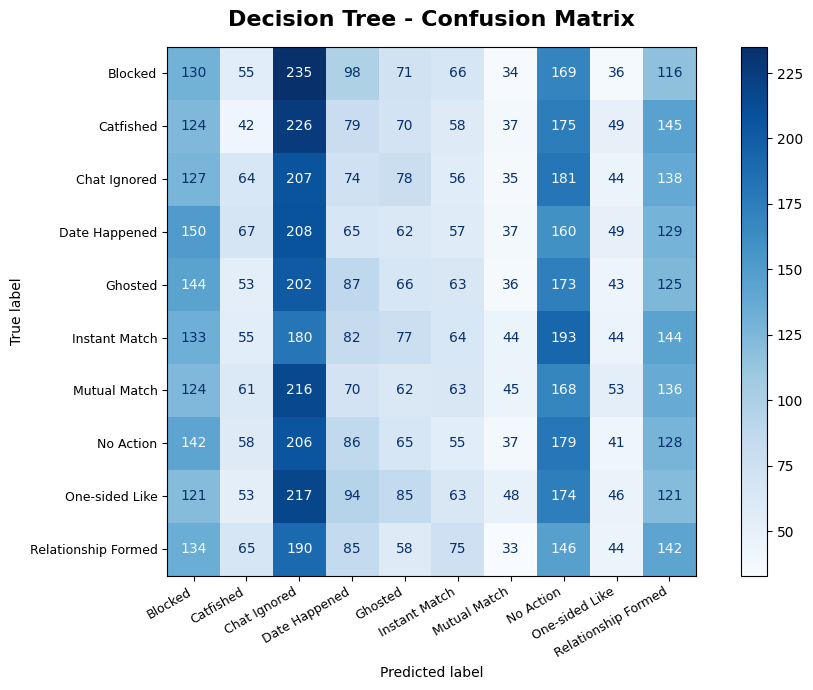

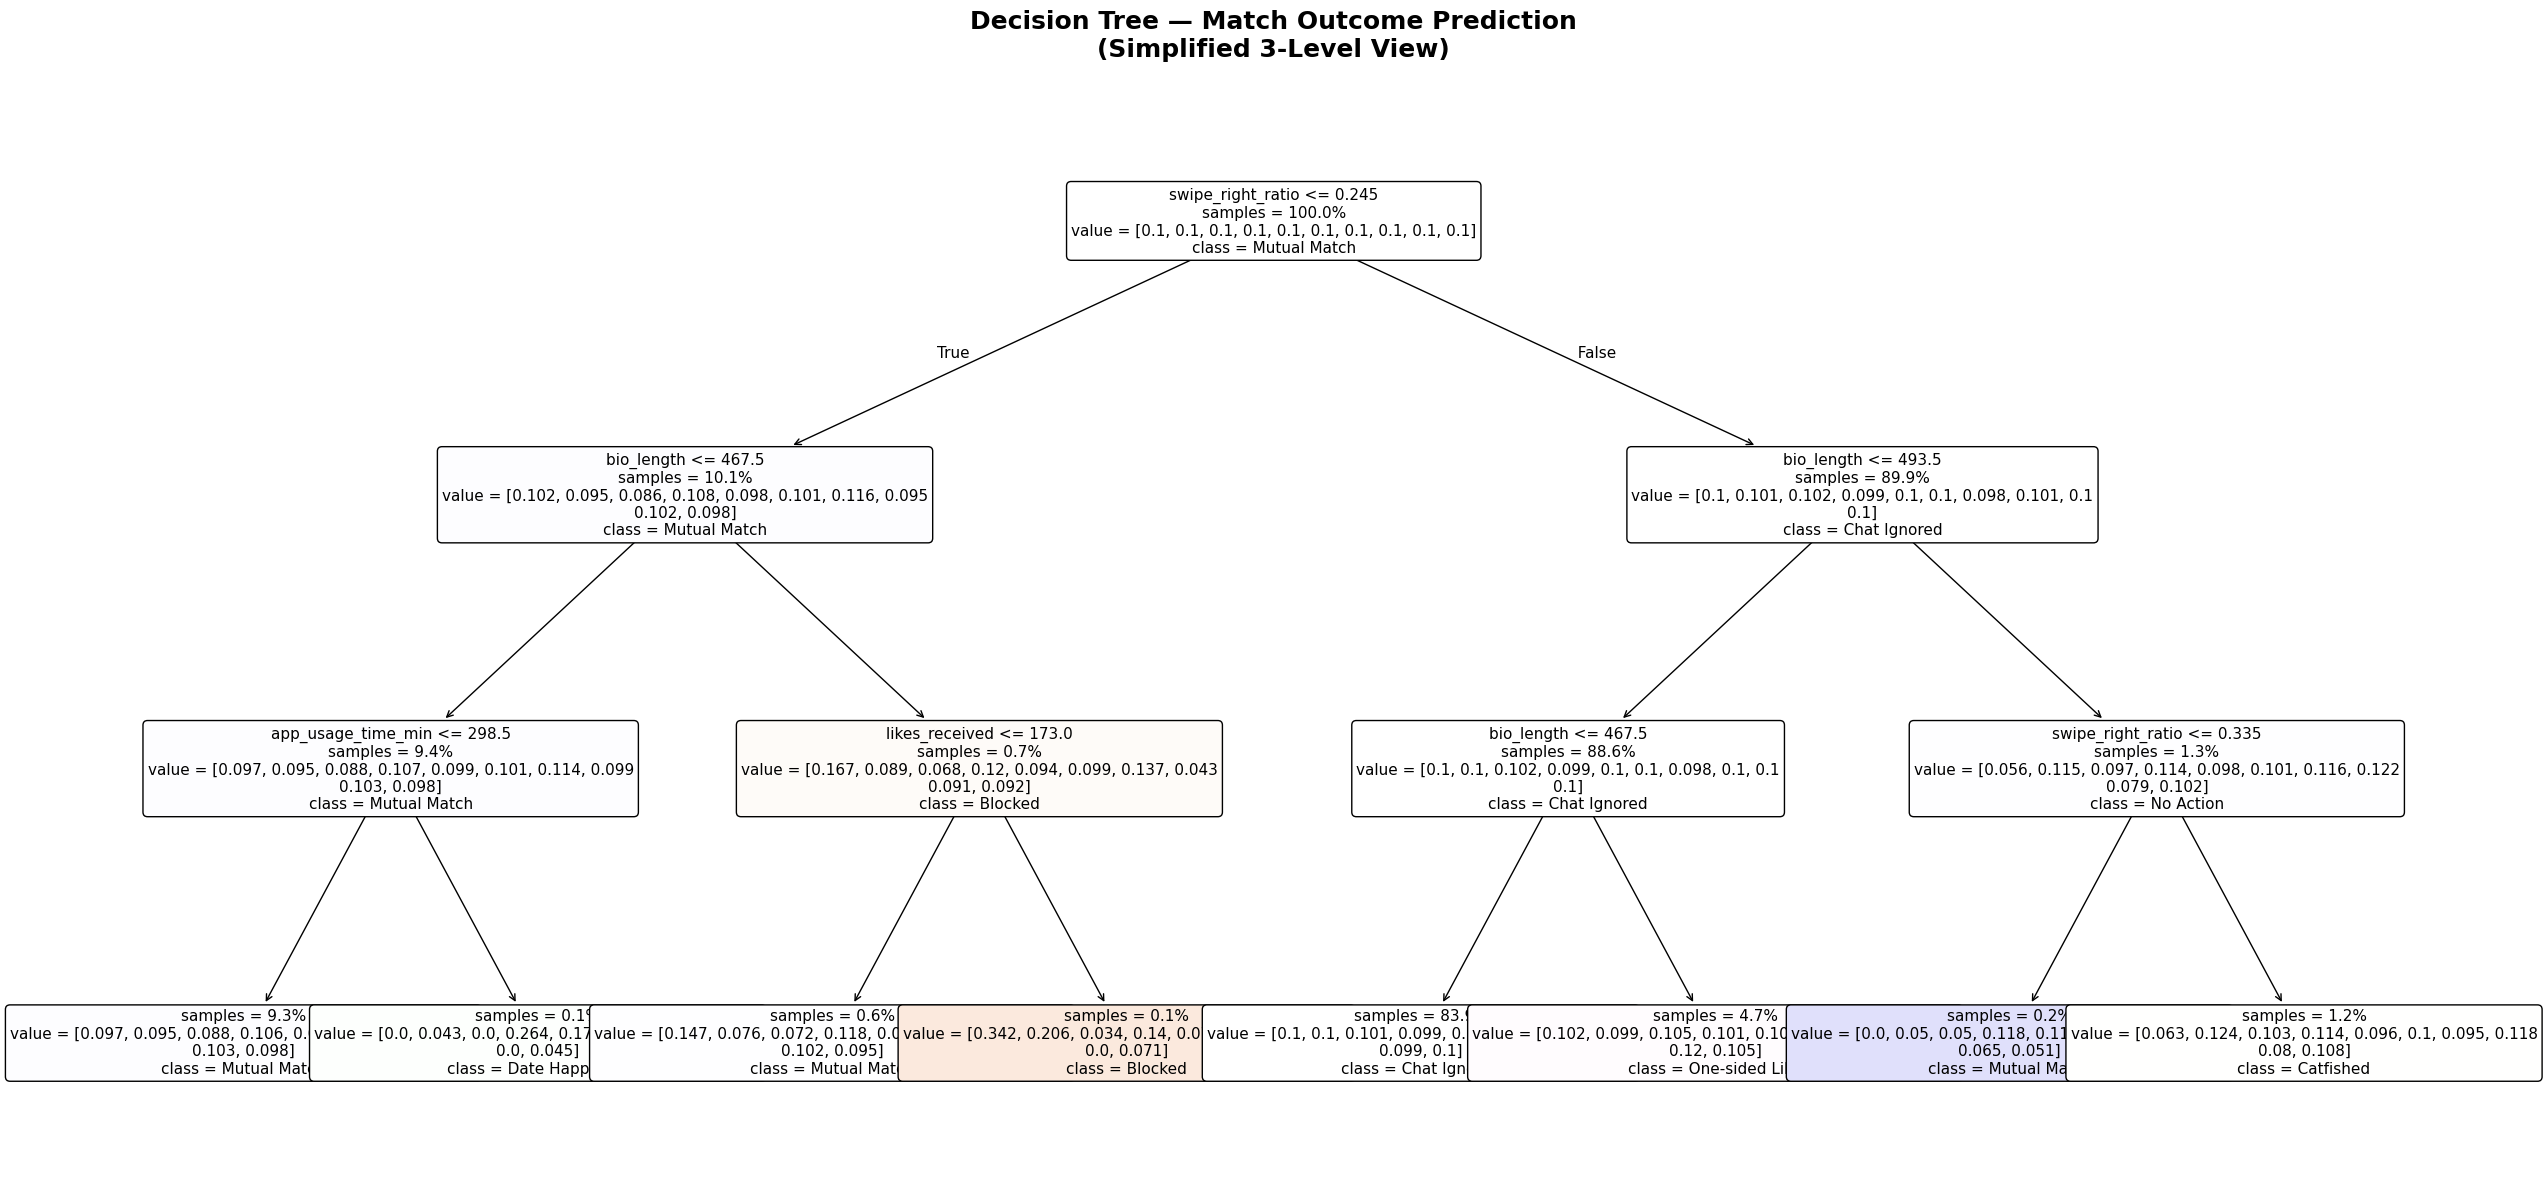


Visualization tree accuracy (3-level): 9.93 %
Full model accuracy (10-level):        9.86 %


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# =========================
# CHECK YOUR TARGET COLUMN
# =========================

print("Match Outcome Classes:")
print(df['match_outcome'].value_counts())
print("\nTotal Classes:", df['match_outcome'].nunique())

# =========================
# FEATURE SELECTION
# =========================

X = df[['swipe_right_ratio',
        'likes_received',
        'mutual_matches',
        'message_sent_count',
        'emoji_usage_rate',
        'app_usage_time_min',
        'profile_pics_count',
        'bio_length',
        'income_bracket',
        'education_level']].copy()

y = df['match_outcome']

# =========================
# ENCODE CATEGORICAL FEATURES
# =========================

for col in ['income_bracket', 'education_level']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("\nEncoded Classes:", target_encoder.classes_)

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================
# ACCURACY TREE (Deep - for performance)
# =========================

dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',       # reduces noisy splits
    class_weight='balanced',   # handles uneven class sizes
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\n=============================")
print("Decision Tree Accuracy:", round(accuracy * 100, 2), "%")
print("=============================\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title("Decision Tree - Confusion Matrix", fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# =========================
# VISUALIZATION TREE (Shallow - for presentation)
# =========================

viz_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,               # ONLY 3 levels — clean and readable
    min_samples_leaf=15,
    class_weight='balanced',
    random_state=42
)

viz_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(26, 12))

plot_tree(
    viz_tree,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax,
    impurity=False,            # hides Gini/entropy clutter
    proportion=True            # shows proportions instead of raw counts
)

plt.title(
    "Decision Tree — Match Outcome Prediction\n(Simplified 3-Level View)",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('decision_tree_clean.png', dpi=150, bbox_inches='tight')  # saves a clean image
plt.show()

print("\nVisualization tree accuracy (3-level):", round(accuracy_score(y_test, viz_tree.predict(X_test)) * 100, 2), "%")
print("Full model accuracy (10-level):       ", round(accuracy * 100, 2), "%")

## Random Forest Model ##

  Random Forest Accuracy: 10.13 %

Classification Report:

                     precision    recall  f1-score   support

            Blocked       0.09      0.10      0.10      1010
          Catfished       0.11      0.11      0.11      1005
       Chat Ignored       0.09      0.09      0.09      1004
      Date Happened       0.11      0.12      0.12       984
            Ghosted       0.11      0.09      0.10       992
      Instant Match       0.10      0.11      0.11      1016
       Mutual Match       0.10      0.09      0.10       998
          No Action       0.09      0.10      0.10       997
     One-sided Like       0.10      0.09      0.10      1022
Relationship Formed       0.11      0.11      0.11       972

           accuracy                           0.10     10000
          macro avg       0.10      0.10      0.10     10000
       weighted avg       0.10      0.10      0.10     10000



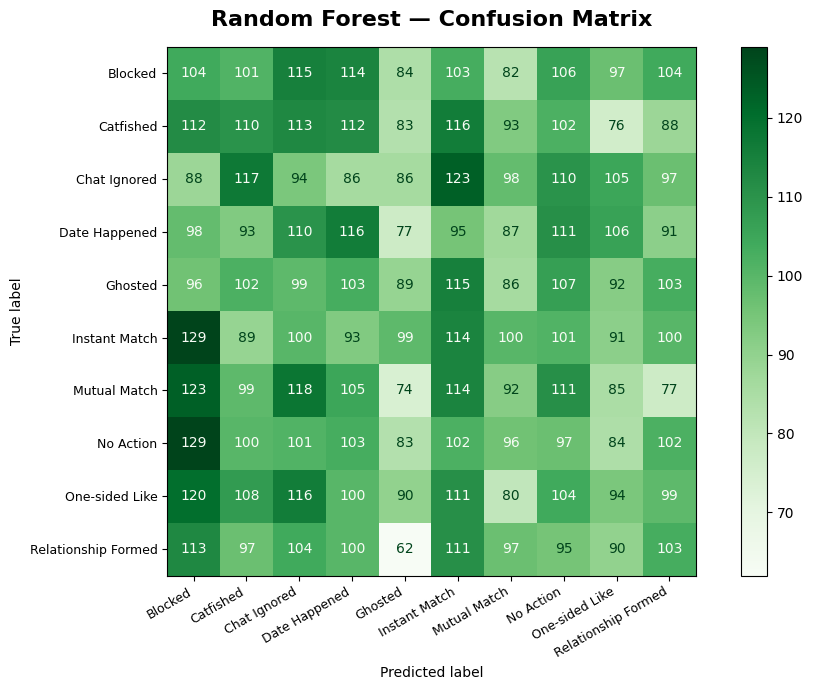

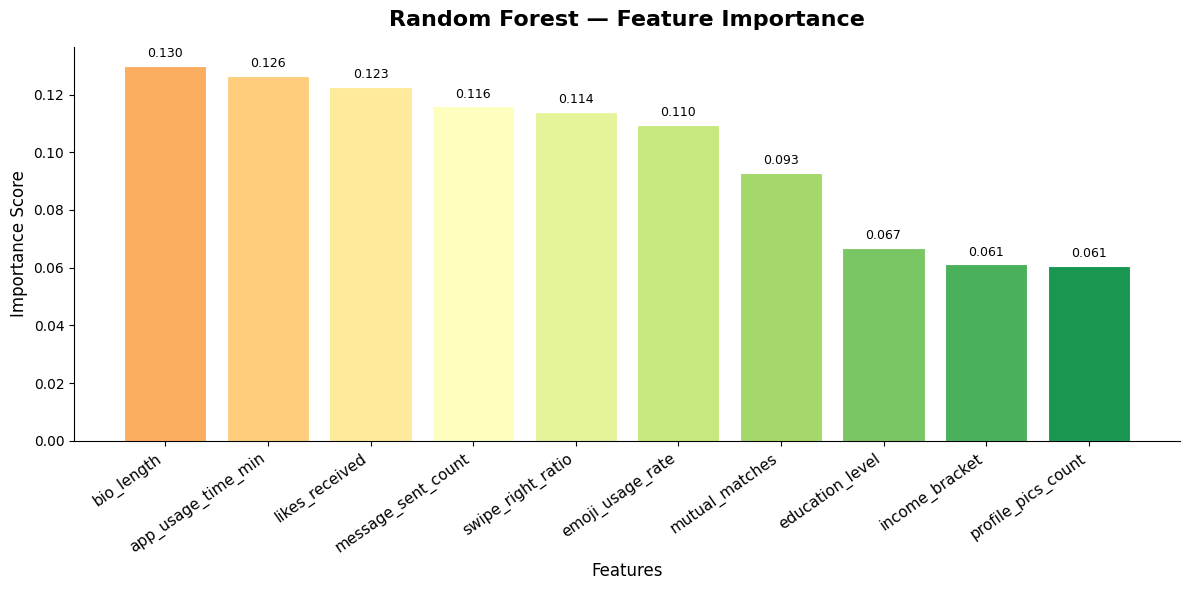

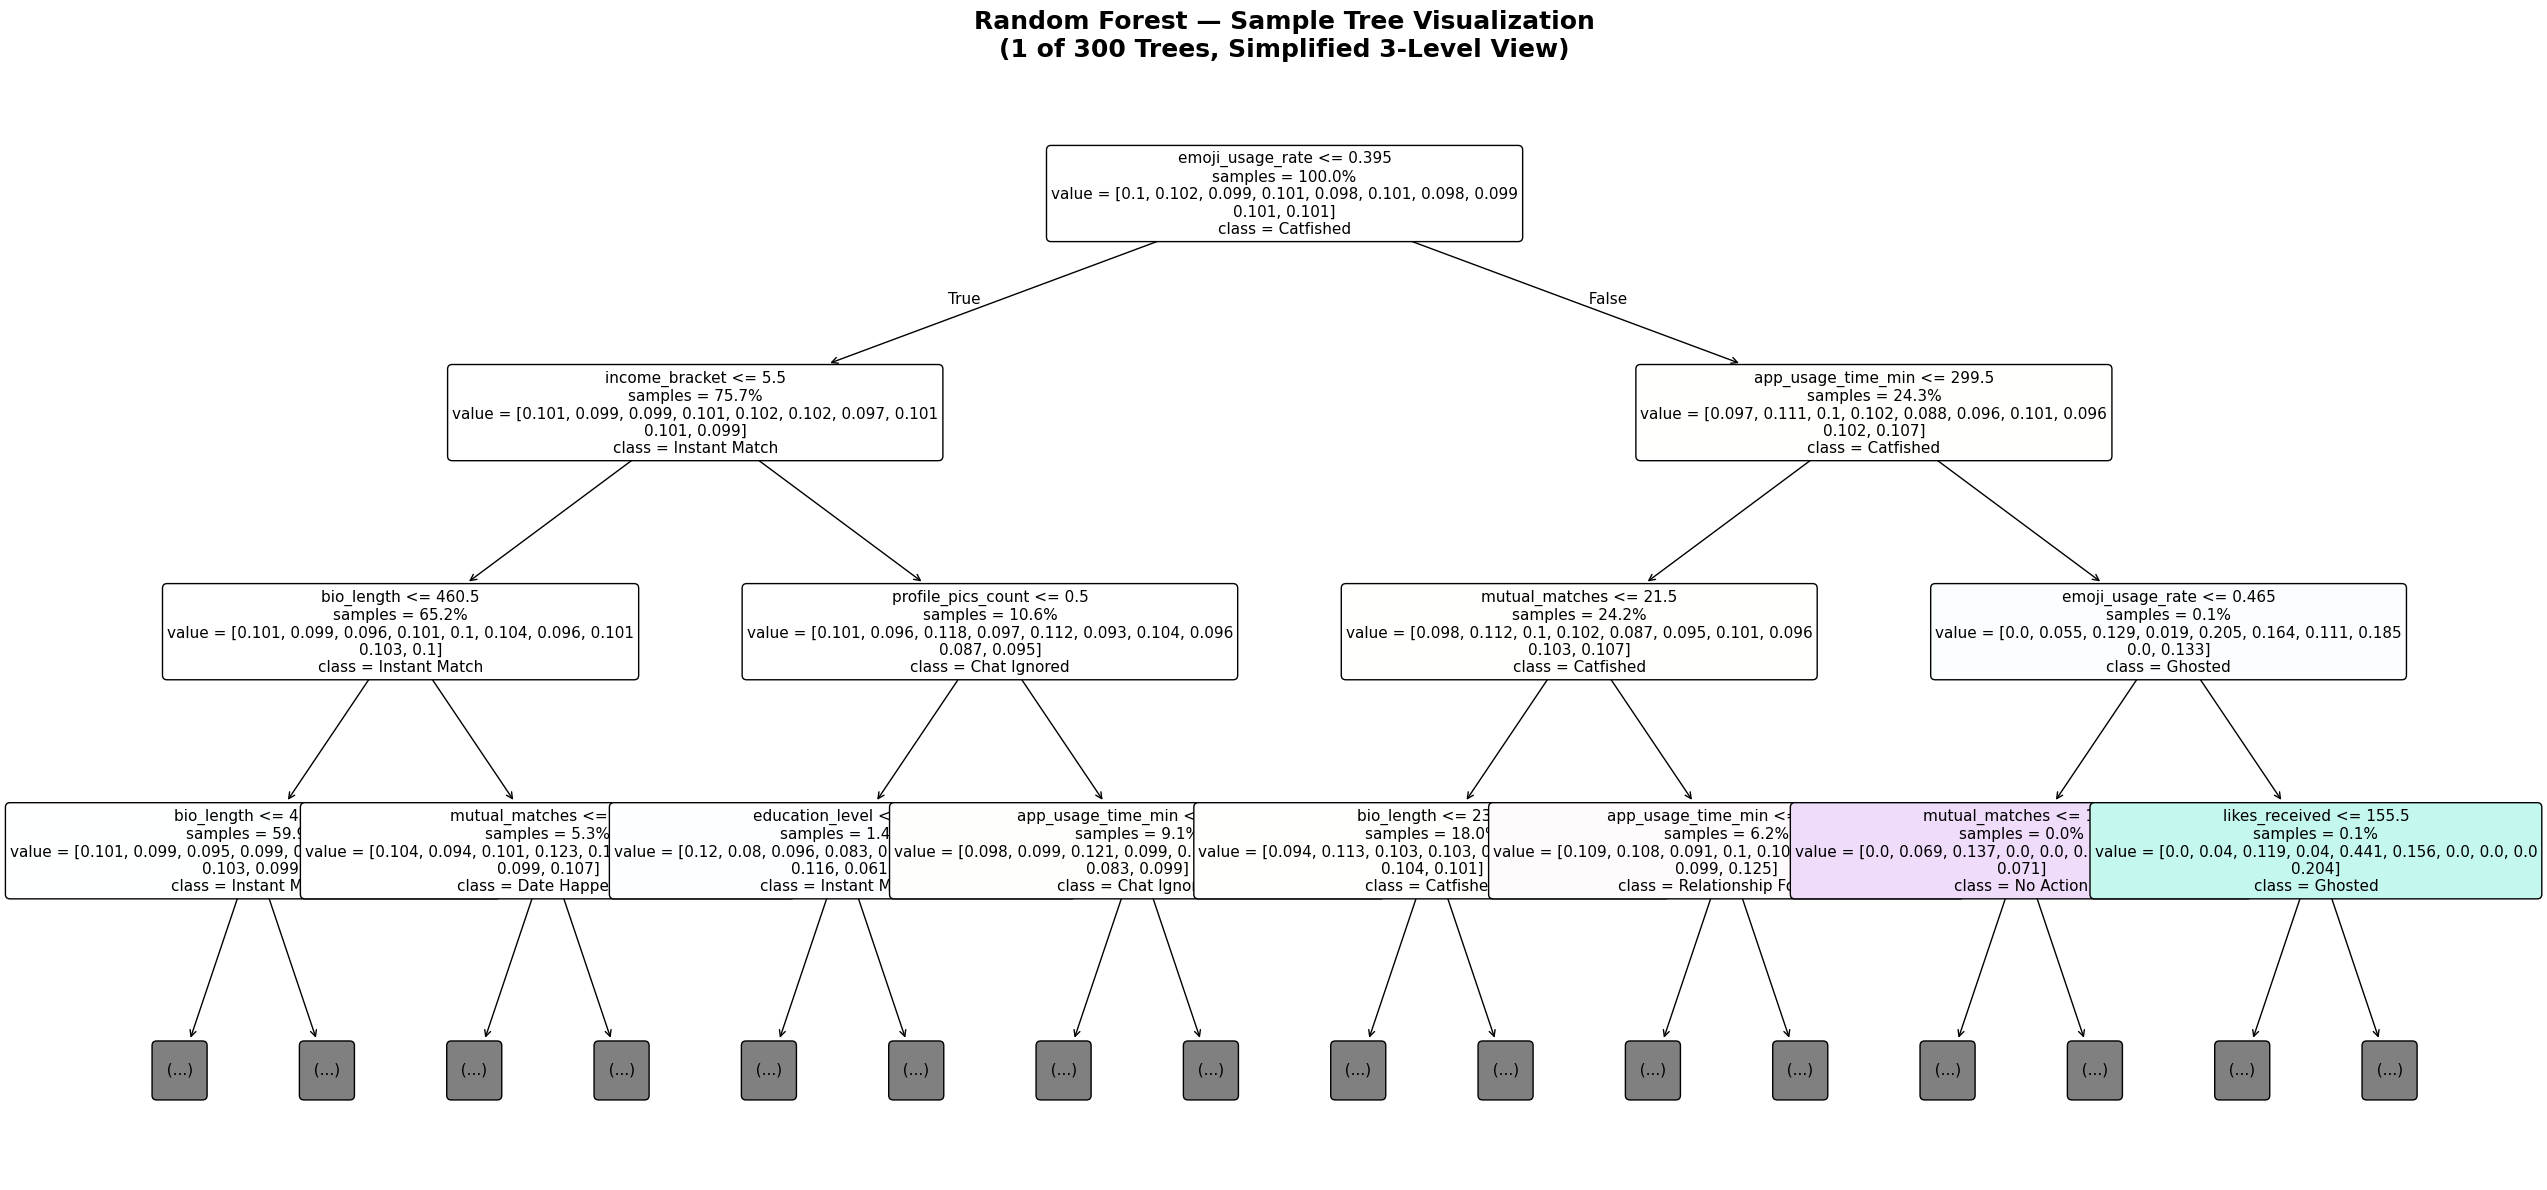


       MODEL COMPARISON SUMMARY
  Random Forest Accuracy : 10.13%
  Trees in Forest        : 300
  Features Used          : 10
  Training Samples       : 40000
  Testing Samples        : 10000


In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================
# FEATURE SELECTION
# =========================

X = df[['swipe_right_ratio',
        'likes_received',
        'mutual_matches',
        'message_sent_count',
        'emoji_usage_rate',
        'app_usage_time_min',
        'profile_pics_count',
        'bio_length',
        'income_bracket',
        'education_level']].copy()

y = df['match_outcome']

# =========================
# ENCODE CATEGORICAL FEATURES
# =========================

for col in ['income_bracket', 'education_level']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================
# RANDOM FOREST MODEL
# =========================

rf_model = RandomForestClassifier(
    n_estimators=300,          # 300 trees = stronger prediction
    criterion='entropy',
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features='sqrt',       # each tree sees a random subset of features
    class_weight='balanced',   # handles uneven class distribution
    bootstrap=True,
    random_state=42,
    n_jobs=-1                  # uses all CPU cores — faster training
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

# =========================
# ACCURACY & REPORT
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("========================================")
print("  Random Forest Accuracy:", round(accuracy * 100, 2), "%")
print("========================================\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 7))
disp.plot(ax=ax, colorbar=True, cmap='Greens')
plt.title("Random Forest — Confusion Matrix", fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# =========================
# FEATURE IMPORTANCE CHART
# =========================

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    range(len(importances)),
    importances[indices],
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances))),
    edgecolor='white',
    linewidth=0.8
)

ax.set_xticks(range(len(importances)))
ax.set_xticklabels(
    [feature_names[i] for i in indices],
    rotation=35,
    ha='right',
    fontsize=11
)

ax.set_title(
    "Random Forest — Feature Importance",
    fontsize=16,
    fontweight='bold',
    pad=15
)
ax.set_ylabel("Importance Score", fontsize=12)
ax.set_xlabel("Features", fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, importances[indices]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('random_forest_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================
# SINGLE TREE VISUALIZATION
# (One sample tree from the forest)
# =========================

sample_tree = rf_model.estimators_[0]

fig, ax = plt.subplots(figsize=(26, 12))

plot_tree(
    sample_tree,
    max_depth=3,               # show only 3 levels — keeps it readable
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    impurity=False,
    proportion=True,
    ax=ax
)

plt.title(
    "Random Forest — Sample Tree Visualization\n(1 of 300 Trees, Simplified 3-Level View)",
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig('random_forest_sample_tree.png', dpi=150, bbox_inches='tight')
plt.show()

# =========================
# COMPARISON SUMMARY
# =========================

print("\n========================================")
print("       MODEL COMPARISON SUMMARY")
print("========================================")
print(f"  Random Forest Accuracy : {round(accuracy * 100, 2)}%")
print(f"  Trees in Forest        : 300")
print(f"  Features Used          : {X.shape[1]}")
print(f"  Training Samples       : {X_train.shape[0]}")
print(f"  Testing Samples        : {X_test.shape[0]}")
print("========================================")

## Description of ML models

#### **Decision Tree Model**
**Purpose**: Predicts match_outcome by learning a series of yes/no rules from the data.

**How it works:**

- Splits data at each node using the feature that best
separates the classes
- Uses Entropy to measure split quality (lower entropy = purer split)
- Keeps splitting until depth limit is reached or leaves are pure enough
- Produces a single, readable tree of decisions

**Key Parameters:**

- criterion='entropy' — measures how mixed each split is
- max_depth=10 — limits tree depth to avoid overfitting
- min_samples_split=5 — node needs ≥5 samples before splitting
- min_samples_leaf=3 — each leaf must contain ≥3 samples
- max_features='sqrt' — only a random subset of - - features considered per split
- class_weight='balanced' — adjusts for uneven class sizes

####**Random Forest Model**

**Purpose:** Builds 300 Decision Trees and combines their votes for a more accurate and reliable prediction.

**How it works:**
- Each of the 300 trees is trained on a different random sample of the data
- Each tree only sees a random subset of features at every split
- Final prediction = majority vote across all 300 trees
- Less prone to overfitting than a single Decision Tree

**Key Parameters:**
- `n_estimators=300` — builds 300 trees
- `criterion='entropy'` — measures split quality
- `max_depth=12` — maximum depth of each tree
- `min_samples_split=5` — minimum samples needed to split a node
- `min_samples_leaf=3` — minimum samples required at each leaf
- `max_features='sqrt'` — each tree uses a random subset of features
- `class_weight='balanced'` — handles uneven class sizes
- `bootstrap=True` — each tree trains on a random resample of data
- `n_jobs=-1` — uses all CPU cores for faster training

---
# Part 5 — XGBoost & AutoML Benchmarking


Two-stage pipeline:
- **Stage 1** — Predict `interest_group` (6 classes) from app behaviour
- **Stage 2** — Use predicted interest + original features to predict `match_outcome` (10 classes)


In [ ]:
!pip install flaml --quiet
!pip install xgboost --quiet
print("Dependencies ready.")

Dependencies ready.


In [ ]:
# Additional imports for Part 5
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split as _tts
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from xgboost import XGBClassifier
from flaml import AutoML as FLAMLAutoML
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Part 5 imports ready.")

Part 5 imports ready.


## Prepare Stage 1 & Stage 2 Targets

The existing pipeline produces `X_train_final` and `X_test_final` with 39,193 and
9,792 rows respectively — Social Activism rows were already dropped when building X.
However `y_train` and `y_test` from the team's original split still contain 40,000
and 10,000 rows (before the drop).

We therefore rebuild both targets from scratch using `df_valid` (Social Activism
excluded) with the exact same split parameters (`test_size=0.2`, `random_state=42`,
`stratify`) so that X and y are guaranteed to align row-for-row.

In [ ]:
# ── Rebuild Stage 1 & Stage 2 targets ────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Step 1: Reload original dataset (all 50,000 rows) ────────────────────────
df_raw = pd.read_csv('dating_app_behavior_dataset.csv')

# ── Step 2: Replicate interest_group mapping ──────────────────────────────────
interest_groups = {
    'Active & Outdoors': ['Fitness', 'Hiking', 'Running', 'Skating', 'MMA', 'Dancing', 'Yoga'],
    'Creative':          ['Art', 'Painting', 'Photography', 'Writing', 'Poetry', 'Crafting', 'DIY'],
    'Entertainment':     ['Clubbing', 'Movies', 'Music', 'Memes', 'Gaming', 'Anime', 'K-pop',
                          'Binge-Watching', 'Stand-up Comedy'],
    'Intellectual':      ['Coding', 'Tech', 'History', 'Politics', 'Reading', 'Podcasts',
                          'Languages', 'Investing', 'Startups'],
    'Lifestyle':         ['Cooking', 'Foodie', 'Fashion', 'Makeup', 'Pets', 'Parenting',
                          'Traveling', 'Tattoos', 'Sneaker Culture'],
    'Mindful':           ['Meditation', 'Spirituality', 'Astrology', 'Gardening',
                          'Board Games', 'Motorcycling', 'Cars']
}
interest_to_group = {interest: group
                     for group, interests in interest_groups.items()
                     for interest in interests}

df_raw['primary_interest'] = df_raw['interest_tags'].str.split(',').str[0].str.strip()
df_raw['interest_group']   = df_raw['primary_interest'].map(interest_to_group)

# ── Step 3: Split from FULL 50,000 rows (exactly as cleaning section did) ─────
_, _, y1_train_raw, y1_test_raw = train_test_split(
    df_raw.drop(columns=['interest_group']),
    df_raw['interest_group'],
    test_size=0.2, random_state=42
)

_, _, y2_train_raw, y2_test_raw = train_test_split(
    df_raw.drop(columns=['match_outcome']),
    df_raw['match_outcome'],
    test_size=0.2, random_state=42
)

# Reset index so positions align with X_train_final (which was also reset)
y1_train_raw = y1_train_raw.reset_index(drop=True)
y1_test_raw  = y1_test_raw.reset_index(drop=True)
y2_train_raw = y2_train_raw.reset_index(drop=True)
y2_test_raw  = y2_test_raw.reset_index(drop=True)

# ── Step 4: Drop NaN rows from y (replicates cleaning section's nan_mask) ─────
# Do this for BOTH y1 and y2 using the SAME mask so rows stay aligned with X
nan_mask_train = y1_train_raw.notna()
nan_mask_test  = y1_test_raw.notna()

y1_train_raw = y1_train_raw[nan_mask_train].reset_index(drop=True)
y1_test_raw  = y1_test_raw[nan_mask_test].reset_index(drop=True)
y2_train_raw = y2_train_raw[nan_mask_train].reset_index(drop=True)
y2_test_raw  = y2_test_raw[nan_mask_test].reset_index(drop=True)

print(f"y1_train after NaN drop: {len(y1_train_raw)}")   # expect 39,193
print(f"y1_test  after NaN drop: {len(y1_test_raw)}")    # expect  9,792

# ── Step 5: Encode both targets ───────────────────────────────────────────────
le_interest      = LabelEncoder()
y1_train_enc     = le_interest.fit_transform(y1_train_raw)
y1_test_enc      = le_interest.transform(y1_test_raw)
interest_classes = le_interest.classes_   # 6 classes

le_match         = LabelEncoder()
y2_train_enc     = le_match.fit_transform(y2_train_raw)
y2_test_enc      = le_match.transform(y2_test_raw)
match_classes    = le_match.classes_      # 10 classes

# ── Verify ────────────────────────────────────────────────────────────────────
print(f"\nX_train_final : {X_train_final.shape}")
print(f"y1_train_enc  : {y1_train_enc.shape}   classes: {interest_classes}")
print(f"y2_train_enc  : {y2_train_enc.shape}   classes: {match_classes}")
assert len(y1_train_enc) == len(X_train_final), "MISMATCH: Stage 1 train"
assert len(y1_test_enc)  == len(X_test_final),  "MISMATCH: Stage 1 test"
assert len(y2_train_enc) == len(X_train_final), "MISMATCH: Stage 2 train"
assert len(y2_test_enc)  == len(X_test_final),  "MISMATCH: Stage 2 test"
print("\n✓ All shapes aligned. Targets ready.")

y1_train after NaN drop: 39193
y1_test  after NaN drop: 9792

X_train_final : (39193, 20)
y1_train_enc  : (39193,)   classes: ['Active & Outdoors' 'Creative' 'Entertainment' 'Intellectual' 'Lifestyle'
 'Mindful']
y2_train_enc  : (39193,)   classes: ['Blocked' 'Catfished' 'Chat Ignored' 'Date Happened' 'Ghosted'
 'Instant Match' 'Mutual Match' 'No Action' 'One-sided Like'
 'Relationship Formed']

✓ All shapes aligned. Targets ready.


## Stage 1: XGBoost — Predicting Interest Group

XGBoost (Extreme Gradient Boosting) is an ensemble method that builds trees sequentially,
where each tree corrects the errors of the previous one. It is well-suited for tabular
classification tasks due to its built-in regularisation, handling of class imbalance via
`scale_pos_weight`, and speed.

| Hyperparameter | Value | Reason |
|---|---|---|
| `n_estimators` | 300 | Enough trees for stable convergence |
| `max_depth` | 6 | Controls overfitting |
| `learning_rate` | 0.1 | Standard starting rate |
| `subsample` | 0.8 | Row sampling per tree — reduces variance |
| `colsample_bytree` | 0.8 | Feature sampling per tree |
| `use_label_encoder` | False | Suppresses deprecation warning |
| `eval_metric` | mlogloss | Multi-class log loss |

In [ ]:
# ── XGBoost Stage 1 — Predict interest_group ────────────────────────
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

xgb_s1 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_s1.fit(X_train_final, y1_train_enc)

xgb_s1_pred      = xgb_s1.predict(X_test_final)
xgb_s1_prob      = xgb_s1.predict_proba(X_test_final)
xgb_s1_accuracy  = accuracy_score(y1_test_enc, xgb_s1_pred)

print(f"XGBoost Stage 1 Accuracy: {round(xgb_s1_accuracy * 100, 2)}%")
print(classification_report(y1_test_enc, xgb_s1_pred,
                             target_names=interest_classes, zero_division=0))

joblib.dump(xgb_s1, 'model_xgb_stage1.pkl')
print("Saved: model_xgb_stage1.pkl")

XGBoost Stage 1 Accuracy: 18.05%
                   precision    recall  f1-score   support

Active & Outdoors       0.15      0.08      0.10      1412
         Creative       0.13      0.06      0.09      1387
    Entertainment       0.19      0.26      0.22      1875
     Intellectual       0.19      0.25      0.22      1829
        Lifestyle       0.19      0.27      0.22      1866
          Mindful       0.16      0.08      0.11      1423

         accuracy                           0.18      9792
        macro avg       0.17      0.17      0.16      9792
     weighted avg       0.17      0.18      0.17      9792

Saved: model_xgb_stage1.pkl


## Stage 1: FLAML AutoML — Automated Baseline

FLAML (Fast and Lightweight AutoML) automatically searches over model types and
hyperparameters within a given time budget. It acts as an automated baseline —
if a manually tuned model cannot outperform FLAML, it signals the hyperparameters
need further work.

FLAML replaces auto-sklearn here because auto-sklearn is incompatible with Python 3.12.

| Setting | Value | Reason |
|---|---|---|
| `time_budget` | 120 | 2 minutes — sufficient for 39K rows |
| `task` | classification | Multi-class classification |
| `metric` | accuracy | Consistent with other models |
| `estimator_list` | ['xgboost','rf','lgbm'] | Fast, tree-based estimators only |
| `verbose` | 0 | Suppresses per-trial output |

In [ ]:
# ── FLAML Stage 1 — Automated baseline for interest_group ────────────
from flaml import AutoML

flaml_s1 = AutoML()
flaml_s1.fit(
    X_train_final, y1_train_enc,
    task='classification',
    metric='accuracy',
    time_budget=120,
    estimator_list=['xgboost', 'rf', 'lgbm'],
    verbose=0
)

flaml_s1_pred     = flaml_s1.predict(X_test_final)
flaml_s1_prob     = flaml_s1.predict_proba(X_test_final)
flaml_s1_accuracy = accuracy_score(y1_test_enc, flaml_s1_pred)

print(f"FLAML Stage 1 Best Model : {flaml_s1.best_estimator}")
print(f"FLAML Stage 1 Accuracy   : {round(flaml_s1_accuracy * 100, 2)}%")
print(classification_report(y1_test_enc, flaml_s1_pred,
                             target_names=interest_classes, zero_division=0))

FLAML Stage 1 Best Model : rf
FLAML Stage 1 Accuracy   : 18.68%
                   precision    recall  f1-score   support

Active & Outdoors       0.25      0.00      0.00      1412
         Creative       0.26      0.01      0.01      1387
    Entertainment       0.18      0.39      0.25      1875
     Intellectual       0.20      0.26      0.22      1829
        Lifestyle       0.18      0.32      0.23      1866
          Mindful       0.27      0.00      0.01      1423

         accuracy                           0.19      9792
        macro avg       0.22      0.16      0.12      9792
     weighted avg       0.22      0.19      0.14      9792



## Stage 2 Pipeline Design

Stage 2 predicts `match_outcome` (10 classes) using the original scaled features
**plus** the interest group predicted by Stage 1.

This appended prediction acts as a new feature, giving Stage 2 models behavioural
context they would not otherwise have from raw app-usage numbers alone.

**Feature matrix for Stage 2:**
`X_train_s2` = `X_train_final` (20 cols) + `xgb_s1_train_pred` (1 col) = 21 features

The Stage 1 prediction used for training is generated via cross-validation
(`cross_val_predict`) to avoid data leakage — the model never sees its own
training predictions as a feature.

In [ ]:
# ── Build Stage 2 feature matrix ────────────────────────────────────
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_predict

# Generate out-of-fold Stage 1 predictions for training set (avoids leakage)
xgb_s1_train_pred = cross_val_predict(
    XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    ),
    X_train_final, y1_train_enc,
    cv=5
)

# For the test set, use the already-trained xgb_s1 predictions
xgb_s1_test_pred = xgb_s1_pred   # from Cell 7

# Append predicted interest group as a new feature column
X_train_s2 = np.hstack([X_train_final, xgb_s1_train_pred.reshape(-1, 1)])
X_test_s2  = np.hstack([X_test_final,  xgb_s1_test_pred.reshape(-1, 1)])

print(f"X_train_s2 shape: {X_train_s2.shape}")   # expect (39193, 21)
print(f"X_test_s2  shape: {X_test_s2.shape}")    # expect  (9792, 21)

X_train_s2 shape: (39193, 21)
X_test_s2  shape: (9792, 21)


## Stage 2: XGBoost — Predicting Match Outcome

Stage 2 uses the same XGBoost architecture as Stage 1, now targeting `match_outcome`
(10 classes). The feature matrix includes the Stage 1 predicted interest group,
giving the model richer context.

`scale_pos_weight` is not used here since XGBoost handles multi-class imbalance
internally via softmax. Class balance will be assessed from the confusion matrix.

In [ ]:
# ── XGBoost Stage 2 — Predict match_outcome ─────────────────────────
xgb_s2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_s2.fit(X_train_s2, y2_train_enc)

xgb_s2_pred     = xgb_s2.predict(X_test_s2)
xgb_s2_prob     = xgb_s2.predict_proba(X_test_s2)
xgb_s2_accuracy = accuracy_score(y2_test_enc, xgb_s2_pred)

print(f"XGBoost Stage 2 Accuracy: {round(xgb_s2_accuracy * 100, 2)}%")
print(classification_report(y2_test_enc, xgb_s2_pred,
                             target_names=match_classes, zero_division=0))

joblib.dump(xgb_s2, 'model_xgb_stage2.pkl')
print("Saved: model_xgb_stage2.pkl")

XGBoost Stage 2 Accuracy: 10.13%
                     precision    recall  f1-score   support

            Blocked       0.10      0.10      0.10      1001
          Catfished       0.10      0.09      0.10      1005
       Chat Ignored       0.10      0.10      0.10       979
      Date Happened       0.12      0.11      0.12       977
            Ghosted       0.10      0.10      0.10       951
      Instant Match       0.10      0.10      0.10       998
       Mutual Match       0.10      0.10      0.10       993
          No Action       0.11      0.12      0.12       934
     One-sided Like       0.10      0.11      0.11       984
Relationship Formed       0.09      0.08      0.08       970

           accuracy                           0.10      9792
          macro avg       0.10      0.10      0.10      9792
       weighted avg       0.10      0.10      0.10      9792

Saved: model_xgb_stage2.pkl


In [ ]:
# ── FLAML Stage 2 — Automated baseline for match_outcome ─────────────
flaml_s2 = AutoML()
flaml_s2.fit(
    X_train_s2, y2_train_enc,
    task='classification',
    metric='accuracy',
    time_budget=120,
    estimator_list=['xgboost', 'rf', 'lgbm'],
    verbose=0
)

flaml_s2_pred     = flaml_s2.predict(X_test_s2)
flaml_s2_prob     = flaml_s2.predict_proba(X_test_s2)
flaml_s2_accuracy = accuracy_score(y2_test_enc, flaml_s2_pred)

print(f"FLAML Stage 2 Best Model : {flaml_s2.best_estimator}")
print(f"FLAML Stage 2 Accuracy   : {round(flaml_s2_accuracy * 100, 2)}%")
print(classification_report(y2_test_enc, flaml_s2_pred,
                             target_names=match_classes, zero_division=0))

FLAML Stage 2 Best Model : lgbm
FLAML Stage 2 Accuracy   : 9.81%
                     precision    recall  f1-score   support

            Blocked       0.08      0.05      0.06      1001
          Catfished       0.14      0.01      0.02      1005
       Chat Ignored       0.09      0.05      0.06       979
      Date Happened       0.00      0.00      0.00       977
            Ghosted       0.09      0.02      0.03       951
      Instant Match       0.10      0.17      0.13       998
       Mutual Match       0.08      0.03      0.04       993
          No Action       0.10      0.07      0.08       934
     One-sided Like       0.10      0.58      0.17       984
Relationship Formed       0.08      0.01      0.01       970

           accuracy                           0.10      9792
          macro avg       0.09      0.10      0.06      9792
       weighted avg       0.09      0.10      0.06      9792



## Collecting All Model Predictions

The cells below gather predictions from all 5 models (Decision Tree, KNN,
Logistic Regression, Random Forest, XGBoost) plus FLAML for both stages.

### Stage 1
Predictions are loaded directly from the saved `.pkl` files produced by teammates
(`model_decision_tree.pkl`, `model_knn.pkl`, `model_logistic_regression.pkl`).
String class labels are encoded to integers using `le_interest` for consistency.

### Stage 2
Rather than requiring manual prediction arrays from teammates, Cell 16 automatically
retrains each Stage 1 model on the Stage 2 feature matrix (`X_train_s2`, 21 features)
against `y2_train_enc`. This ensures all Stage 2 models see the same enriched feature
set — including the predicted interest group appended in Cell 11.

Random Forest has no saved `.pkl` and is reconstructed using the same hyperparameters
defined in the shared notebook before retraining.

> **Note for teammates:** No manual changes to Cell 16 are needed. Ensure your
> saved `.pkl` files are present in the Colab working directory before running.

In [ ]:
# ── Collect all model predictions ───────────────────────────────────
import joblib
import numpy as np
from sklearn.metrics import accuracy_score

# ── Helper: auto-retrain a Stage 1 model for Stage 2 ─────────────────────────
def retrain_for_stage2(pkl_path, X_tr, y_tr, X_te):
    """
    Load a saved Stage 1 model, clone its config, retrain on Stage 2
    feature matrix (X_train_s2), and return test predictions.
    """
    from sklearn.base import clone
    base_model = joblib.load(pkl_path)
    s2_model   = clone(base_model)
    s2_model.fit(X_tr, y_tr)
    return s2_model.predict(X_te)

# ── Stage 1: load from saved .pkl files ──────────────────────────────────────
dt_model  = joblib.load('model_decision_tree.pkl')
knn_model = joblib.load('model_knn.pkl')
lr_model  = joblib.load('model_logistic_regression.pkl')

# Teammates' Stage 1 models predict interest_group as strings — encode to int
dt_s1_pred  = le_interest.transform(dt_model.predict(X_test_final))
knn_s1_pred = le_interest.transform(knn_model.predict(X_test_final))
lr_s1_pred  = le_interest.transform(lr_model.predict(X_test_final))

# ── Stage 2: auto-retrain each teammate model on X_train_s2 / y2_train_enc ───
print("Retraining teammate models for Stage 2...")

dt_s2_pred  = retrain_for_stage2('model_decision_tree.pkl',
                                  X_train_s2, y2_train_enc, X_test_s2)
knn_s2_pred = retrain_for_stage2('model_knn.pkl',
                                  X_train_s2, y2_train_enc, X_test_s2)
lr_s2_pred  = retrain_for_stage2('model_logistic_regression.pkl',
                                  X_train_s2, y2_train_enc, X_test_s2)

# Random Forest has no saved .pkl — reconstruct with same config as notebook
from sklearn.ensemble import RandomForestClassifier
rf_s2 = RandomForestClassifier(
    n_estimators=300, criterion='entropy', max_depth=12,
    min_samples_split=5, min_samples_leaf=3, max_features='sqrt',
    class_weight='balanced', bootstrap=True, random_state=42, n_jobs=-1
)
rf_s2.fit(X_train_s2, y2_train_enc)
rf_s2_pred = rf_s2.predict(X_test_s2)

print("Done. Stage 2 prediction shapes:")
for name, arr in [("DT",  dt_s2_pred), ("KNN", knn_s2_pred),
                  ("LR",  lr_s2_pred), ("RF",  rf_s2_pred),
                  ("XGB", xgb_s2_pred), ("FLAML", flaml_s2_pred)]:
    print(f"  {name}: {arr.shape}")

# ── Quick sanity check ────────────────────────────────────────────────────────
print("\nStage 2 accuracies (sanity check):")
for name, arr in [("DT",  dt_s2_pred), ("KNN", knn_s2_pred),
                  ("LR",  lr_s2_pred), ("RF",  rf_s2_pred),
                  ("XGB", xgb_s2_pred), ("FLAML", flaml_s2_pred)]:
    print(f"  {name}: {round(accuracy_score(y2_test_enc, arr) * 100, 2)}%")

Retraining teammate models for Stage 2...
Done. Stage 2 prediction shapes:
  DT: (9792,)
  KNN: (9792,)
  LR: (9792,)
  RF: (9792,)
  XGB: (9792,)
  FLAML: (9792,)

Stage 2 accuracies (sanity check):
  DT: 9.62%
  KNN: 9.89%
  LR: 9.46%
  RF: 9.66%
  XGB: 10.13%
  FLAML: 9.81%


## Model Comparison — Accuracy & F1

We compare all models on two metrics:
- **Accuracy**: proportion of correctly classified samples
- **Macro F1**: unweighted mean F1 across all classes — penalises models that
  perform well on majority classes but poorly on minority ones

Both stages are evaluated separately.

═════════════════════════════════════════════
  STAGE 1 — Interest Group Prediction
═════════════════════════════════════════════
              Model  Accuracy  Macro F1
              FLAML    0.1868    0.1216
            XGBoost    0.1805    0.1593
                KNN    0.1768    0.1691
Logistic Regression    0.1680    0.1638
      Decision Tree    0.1675    0.1648

═════════════════════════════════════════════
  STAGE 2 — Match Outcome Prediction
═════════════════════════════════════════════
              Model  Accuracy  Macro F1
            XGBoost    0.1013    0.1012
                KNN    0.0989    0.0988
              FLAML    0.0981    0.0607
      Random Forest    0.0966    0.0965
      Decision Tree    0.0962    0.0961
Logistic Regression    0.0946    0.0896


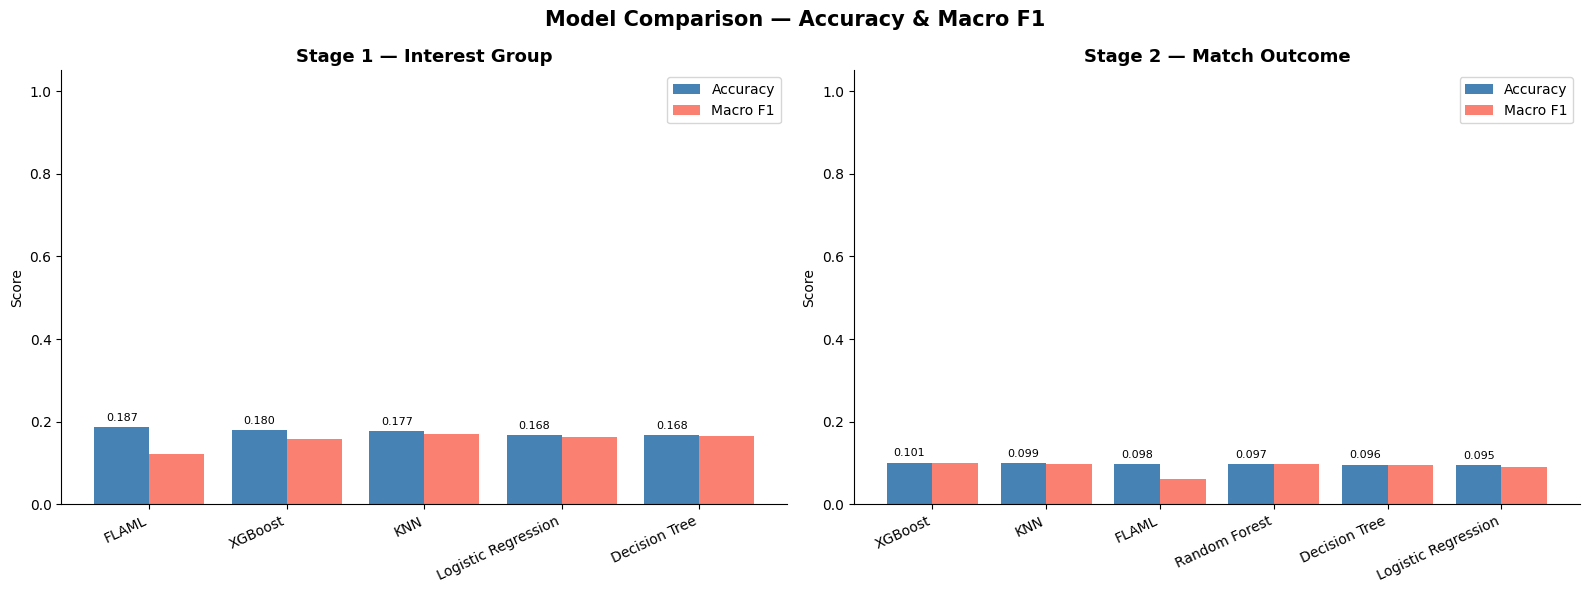

In [ ]:
# ── Comparison tables + bar chart ───────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

def evaluate(name, y_true, y_pred):
    return {
        'Model':    name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Macro F1': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4)
    }

# ── Stage 1 ───────────────────────────────────────────────────────────────────
s1_results = pd.DataFrame([
    evaluate('Decision Tree',       y1_test_enc, dt_s1_pred),
    evaluate('KNN',                 y1_test_enc, knn_s1_pred),
    evaluate('Logistic Regression', y1_test_enc, lr_s1_pred),
    evaluate('XGBoost',             y1_test_enc, xgb_s1_pred),
    evaluate('FLAML',               y1_test_enc, flaml_s1_pred),
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("═" * 45)
print("  STAGE 1 — Interest Group Prediction")
print("═" * 45)
print(s1_results.to_string(index=False))

# ── Stage 2 ───────────────────────────────────────────────────────────────────
s2_results = pd.DataFrame([
    evaluate('Decision Tree',       y2_test_enc, dt_s2_pred),
    evaluate('KNN',                 y2_test_enc, knn_s2_pred),
    evaluate('Logistic Regression', y2_test_enc, lr_s2_pred),
    evaluate('Random Forest',       y2_test_enc, rf_s2_pred),
    evaluate('XGBoost',             y2_test_enc, xgb_s2_pred),
    evaluate('FLAML',               y2_test_enc, flaml_s2_pred),
]).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "═" * 45)
print("  STAGE 2 — Match Outcome Prediction")
print("═" * 45)
print(s2_results.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, results, title in [
    (axes[0], s1_results, 'Stage 1 — Interest Group'),
    (axes[1], s2_results, 'Stage 2 — Match Outcome')
]:
    x = range(len(results))
    bars = ax.bar(x, results['Accuracy'], width=0.4, label='Accuracy',
                  color='steelblue', align='center')
    ax.bar([i + 0.4 for i in x], results['Macro F1'], width=0.4,
           label='Macro F1', color='salmon', align='center')
    ax.set_xticks([i + 0.2 for i in x])
    ax.set_xticklabels(results['Model'], rotation=25, ha='right', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison — Accuracy & Macro F1', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrices

Confusion matrices show the breakdown of correct and incorrect predictions per class.
Rows represent actual labels; columns represent predicted labels.
Values are normalised to percentages per actual class (row-wise) so class size
differences do not distort the visual.

We show matrices for XGBoost and FLAML only, for both stages.

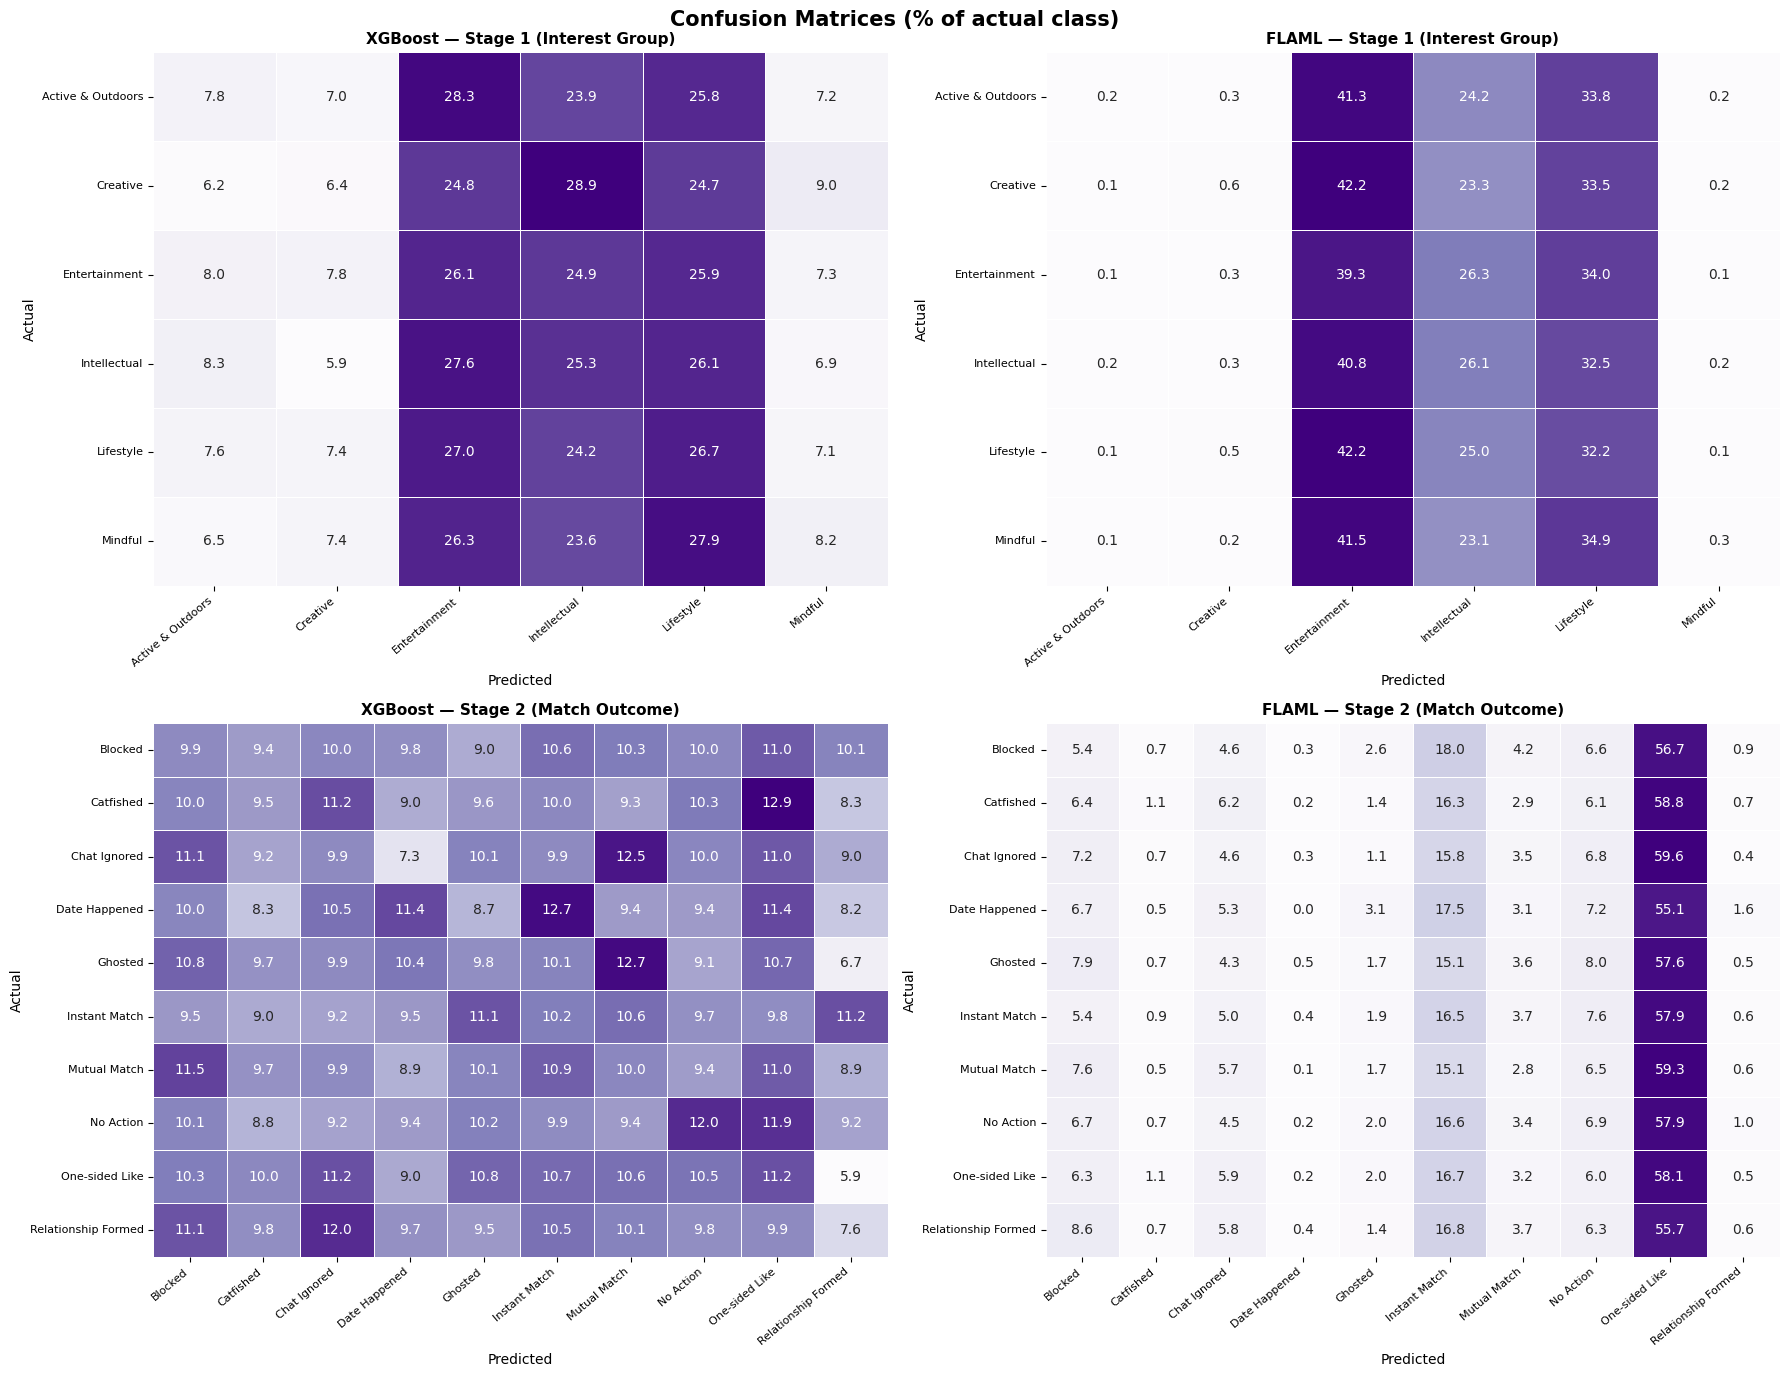

In [ ]:
# ── Confusion matrices — XGBoost + FLAML, both stages ───────────────
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_cm(ax, y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Purples',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

plot_cm(axes[0][0], y1_test_enc, xgb_s1_pred,  interest_classes,
        'XGBoost — Stage 1 (Interest Group)')
plot_cm(axes[0][1], y1_test_enc, flaml_s1_pred, interest_classes,
        'FLAML — Stage 1 (Interest Group)')
plot_cm(axes[1][0], y2_test_enc, xgb_s2_pred,  match_classes,
        'XGBoost — Stage 2 (Match Outcome)')
plot_cm(axes[1][1], y2_test_enc, flaml_s2_pred, match_classes,
        'FLAML — Stage 2 (Match Outcome)')

plt.suptitle('Confusion Matrices (% of actual class)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC Curves

ROC curves plot True Positive Rate vs False Positive Rate at varying thresholds.
AUC (Area Under Curve) summarises performance — 1.0 is perfect, 0.5 is random.

For multi-class problems we use the One-vs-Rest (OvR) strategy: one curve per class.
We plot XGBoost and FLAML curves for both stages.

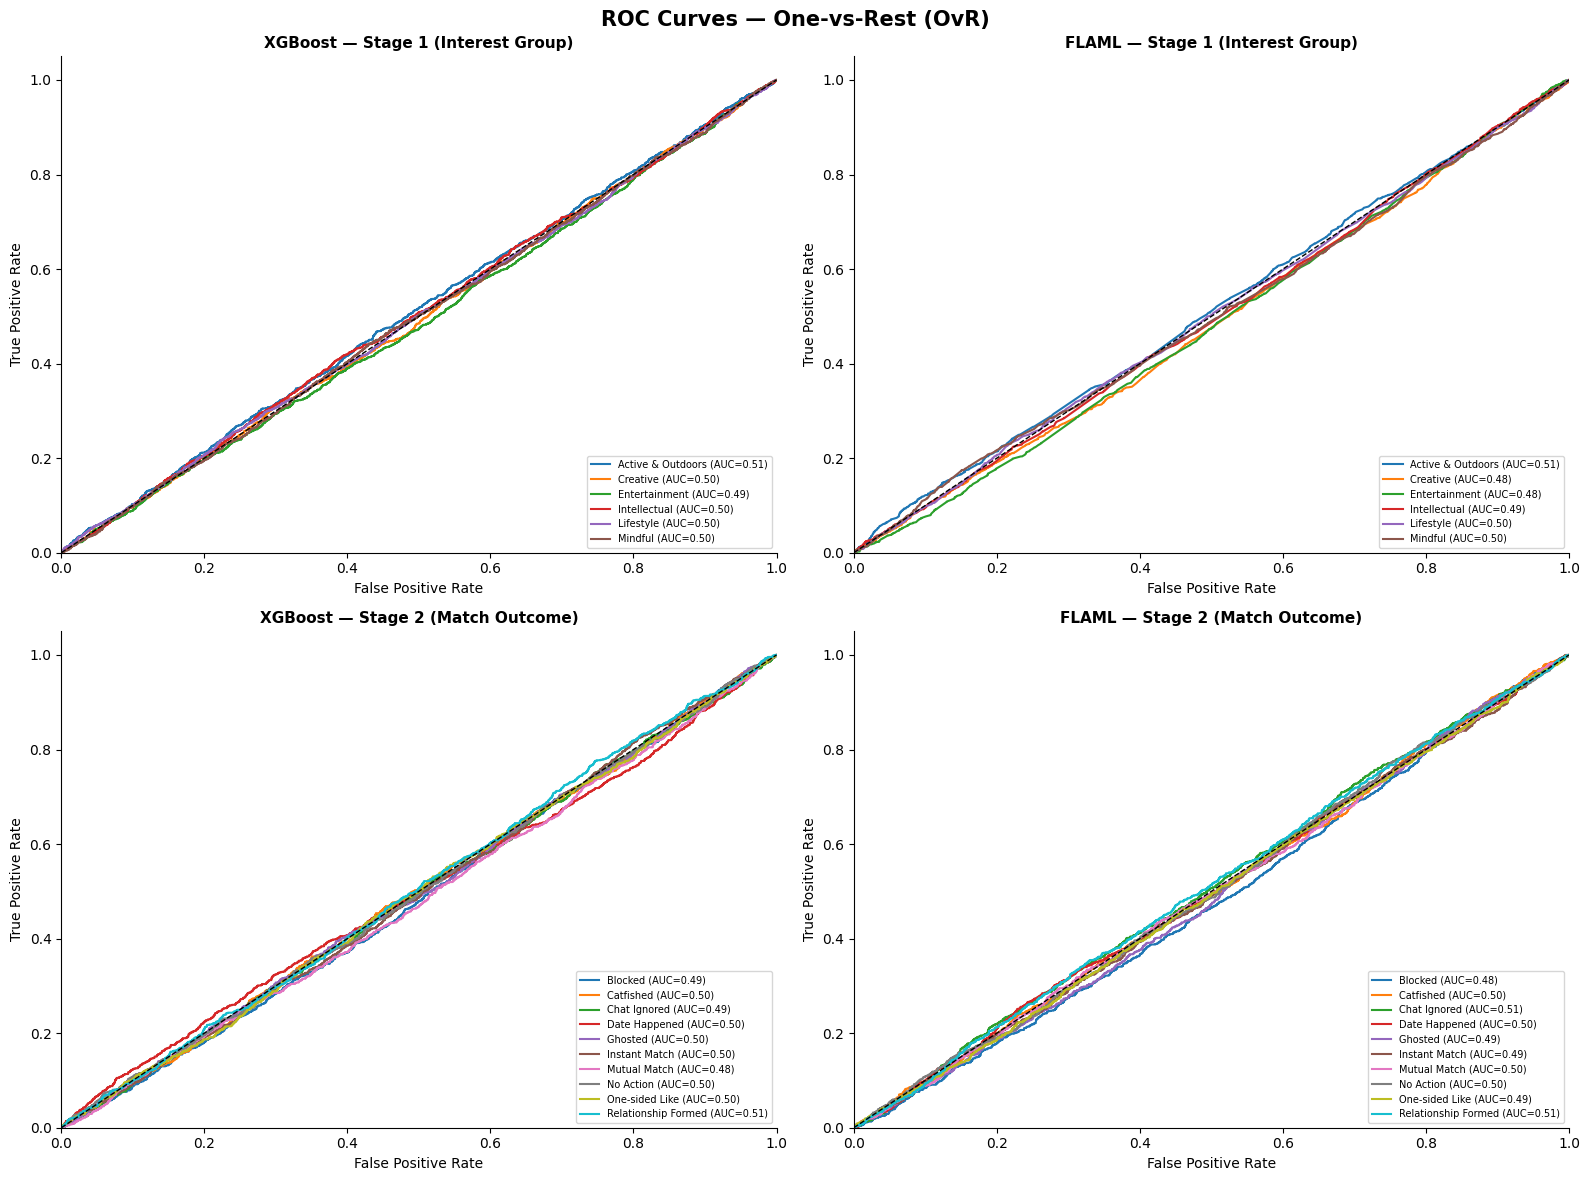

In [ ]:
# ── ROC curves — XGBoost + FLAML, both stages ───────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_roc(ax, y_true, y_prob, class_names, title):
    n_classes = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    colors = plt.cm.tab10(range(n_classes))
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{cls} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_roc(axes[0][0], y1_test_enc, xgb_s1_prob,  interest_classes,
         'XGBoost — Stage 1 (Interest Group)')
plot_roc(axes[0][1], y1_test_enc, flaml_s1_prob, interest_classes,
         'FLAML — Stage 1 (Interest Group)')
plot_roc(axes[1][0], y2_test_enc, xgb_s2_prob,  match_classes,
         'XGBoost — Stage 2 (Match Outcome)')
plot_roc(axes[1][1], y2_test_enc, flaml_s2_prob, match_classes,
         'FLAML — Stage 2 (Match Outcome)')

plt.suptitle('ROC Curves — One-vs-Rest (OvR)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance

XGBoost provides a built-in feature importance score (`weight` — number of times a
feature is used to split across all trees). Higher score = more influential feature.

We plot importance for both Stage 1 and Stage 2 models. The Stage 2 plot includes
the appended `predicted_interest` feature, showing whether Stage 1's output
contributed meaningfully to Stage 2 predictions.

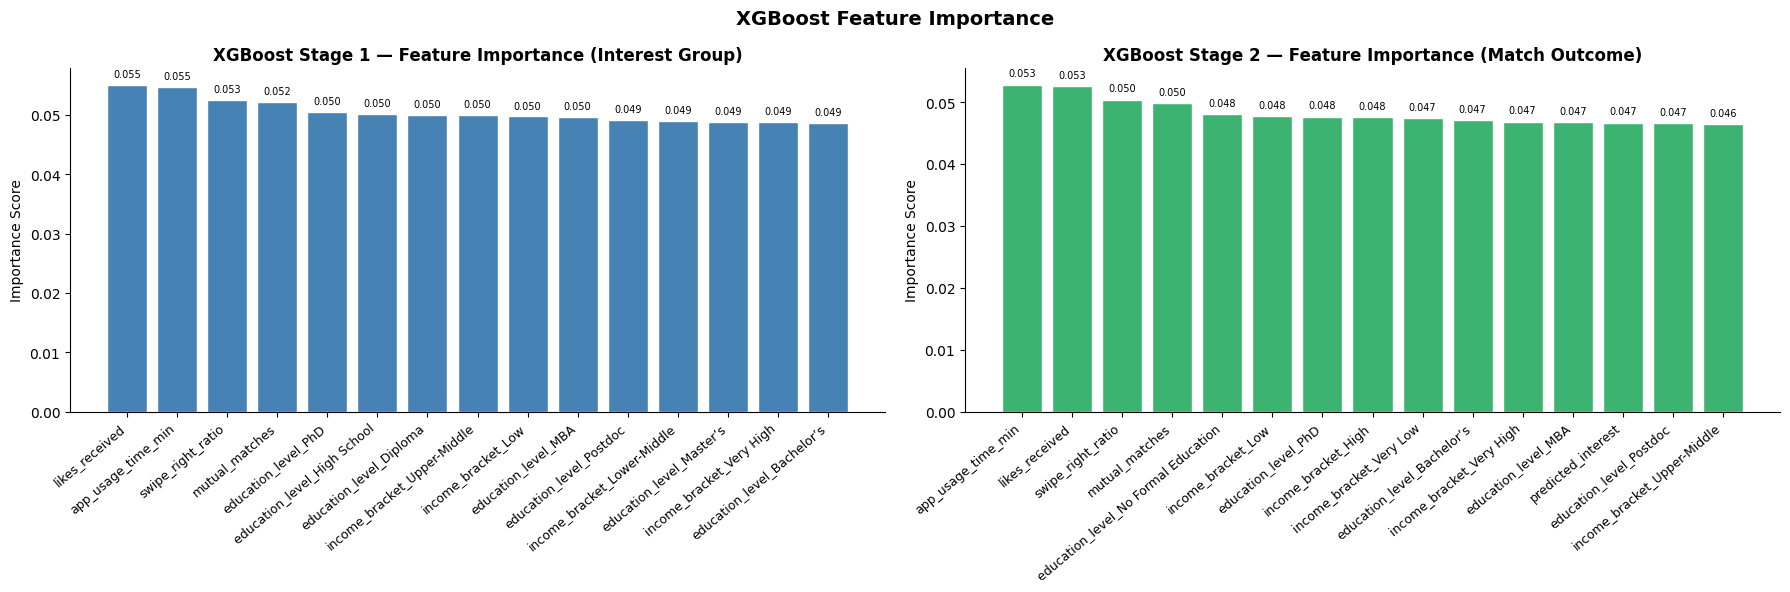

In [ ]:
# ── Feature importance — XGBoost Stage 1 + Stage 2 ──────────────────
import matplotlib.pyplot as plt
import numpy as np

# Feature names: Stage 1 uses X_train_final columns
s1_feature_names = list(X_train_final.columns)

# Stage 2 adds predicted_interest as the last column
s2_feature_names = s1_feature_names + ['predicted_interest']

def plot_importance(ax, model, feature_names, title, color):
    importances = model.feature_importances_
    indices     = np.argsort(importances)[::-1]
    top_n       = min(15, len(feature_names))
    idx         = indices[:top_n]

    bars = ax.bar(range(top_n), importances[idx], color=color, edgecolor='white')
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([feature_names[i] for i in idx],
                       rotation=40, ha='right', fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Importance Score', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plot_importance(axes[0], xgb_s1, s1_feature_names,
                'XGBoost Stage 1 — Feature Importance (Interest Group)', 'steelblue')
plot_importance(axes[1], xgb_s2, s2_feature_names,
                'XGBoost Stage 2 — Feature Importance (Match Outcome)', 'mediumseagreen')

plt.suptitle('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 25: Final summary ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════╗")
print("║           FINAL MODEL COMPARISON SUMMARY                ║")
print("╠══════════════════════════════════════════════════════════╣")
print("║  STAGE 1 — Interest Group (6 classes)                   ║")
print("╠══════════════════════════════════════════════════════════╣")
print(s1_results.to_string(index=False))
print("╠══════════════════════════════════════════════════════════╣")
print("║  STAGE 2 — Match Outcome (10 classes)                   ║")
print("╠══════════════════════════════════════════════════════════╣")
print(s2_results.to_string(index=False))
print("╠══════════════════════════════════════════════════════════╣")

best_s1 = s1_results.iloc[0]
best_s2 = s2_results.iloc[0]
print(f"║  Best Stage 1 model : {best_s1['Model']:<20} Acc={best_s1['Accuracy']:.4f}  ║")
print(f"║  Best Stage 2 model : {best_s2['Model']:<20} Acc={best_s2['Accuracy']:.4f}  ║")
print("╚══════════════════════════════════════════════════════════╝")

print("\nFiles saved:")
for f in ['model_xgb_stage1.pkl', 'model_xgb_stage2.pkl',
          'model_comparison.png', 'confusion_matrices.png',
          'roc_curves.png', 'feature_importance.png']:
    print(f"  ✓ {f}")

╔══════════════════════════════════════════════════════════╗
║           FINAL MODEL COMPARISON SUMMARY                ║
╠══════════════════════════════════════════════════════════╣
║  STAGE 1 — Interest Group (6 classes)                   ║
╠══════════════════════════════════════════════════════════╣
              Model  Accuracy  Macro F1
              FLAML    0.1868    0.1216
            XGBoost    0.1805    0.1593
                KNN    0.1768    0.1691
Logistic Regression    0.1680    0.1638
      Decision Tree    0.1675    0.1648
╠══════════════════════════════════════════════════════════╣
║  STAGE 2 — Match Outcome (10 classes)                   ║
╠══════════════════════════════════════════════════════════╣
              Model  Accuracy  Macro F1
            XGBoost    0.1013    0.1012
                KNN    0.0989    0.0988
              FLAML    0.0981    0.0607
      Random Forest    0.0966    0.0965
      Decision Tree    0.0962    0.0961
Logistic Regression    0.0946    0.